In [4]:
library(Seurat)
library(harmony)

library(ggplot2)
library(ggbeeswarm)
library(ggplotify)
library(ggsci)
library(scatterpie)
library(patchwork)
library(ggrastr)

library(ComplexHeatmap)
library(grid)
library(circlize)

In [5]:
multi_colpalettes <- unique(c(pal_igv("default")(51),pal_npg("nrc")(10),pal_aaas("default")(10),pal_nejm("default")(8),pal_lancet("lanonc")(9),
                      pal_jama("default")(7),pal_jco("default")(10),pal_ucscgb("default")(26),pal_d3("category10")(10),
                      pal_locuszoom("default")(7),
                      pal_uchicago("default")(9),pal_startrek("uniform")(7),
                      pal_tron("legacy")(7),pal_futurama("planetexpress")(12),pal_rickandmorty("schwifty")(12),
                      pal_simpsons("springfield")(16),pal_gsea("default")(12)))

In [6]:
Class_color <- c('#F0E685FF','#CE3D32FF','#5DB1DDFF','#466983FF',
                 '#5050FFFF','#837B8DFF','#BA6338FF','#802268FF','#6BD76BFF','#D595A7FF','#924822FF','#749B58FF')
names(Class_color) <- c('GLU','CGE','MGE','LGE',
                        'AST','EPC','MG','NB','OLG','OPC','VLMC','EC')

Archr_col <- c('#D51F26','#272E6A','#208A42','#89288F','#F47D2B','#FEE500','#8A9FD1',
               '#C06CAB','#E6C2DC','#90D5E4','#89C75F','#F37B7D','#9983BD','#D24B27',
               '#3BBCA8','#6E4B9E','#0C727C','#7E1416','#D8A767')
Subclass_color <- Archr_col[1:17]
names(Subclass_color) <- c('MGE.PVALB','MGE.PVALB-POSTN','MGE.SST','CGE.VIP','CGE.LAMP5','CGE.LAMP5-PRKG1','CGE.LAMP5-RELN','CGE.RELN','LGE.TSHZ1','LGE.FOXP1',
                           'Upper-IT','Middle-IT','Deep-IT','Deep-CT','Deep-PT','Deep-NP','Deep-RGS12')

Species_color <- c('#2A6EBBFF','#F0AB00FF','#C50084FF','#7D5CC6FF','#E37222FF','#69BE28FF','#00B2A9FF')
names(Species_color) <- c('marm','mous','bird','turt','axol','lung','lamp')

In [ ]:
source('../R_function/Seurat_function.R')
source('../R_function/knn_function.R')
source('../R_function/calculate_function.R')

In [8]:
obj_IN <- readRDS('Analysis/obj_GABA_integrated_final.rds')
obj_EX <- readRDS('Analysis/obj_GLU_integrated_final.rds')

In [ ]:
source('../R_function/Seurat_function.R') # nolint: quotes_linter.
obj_IN <- read_seurat_key(obj_IN ,path = 'Analysis/obj_GABA_integrated_final_20260206_keys.rds')
obj_EX <- read_seurat_key(obj_EX ,path = 'Analysis/obj_GLU_integrated_final_20260206_keys.rds')

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




In [ ]:
saveRDS(obj_IN,'Analysis/obj_GABA_integrated_final.rds')
saveRDS(obj_EX,'Analysis/obj_GLU_integrated_final.rds')

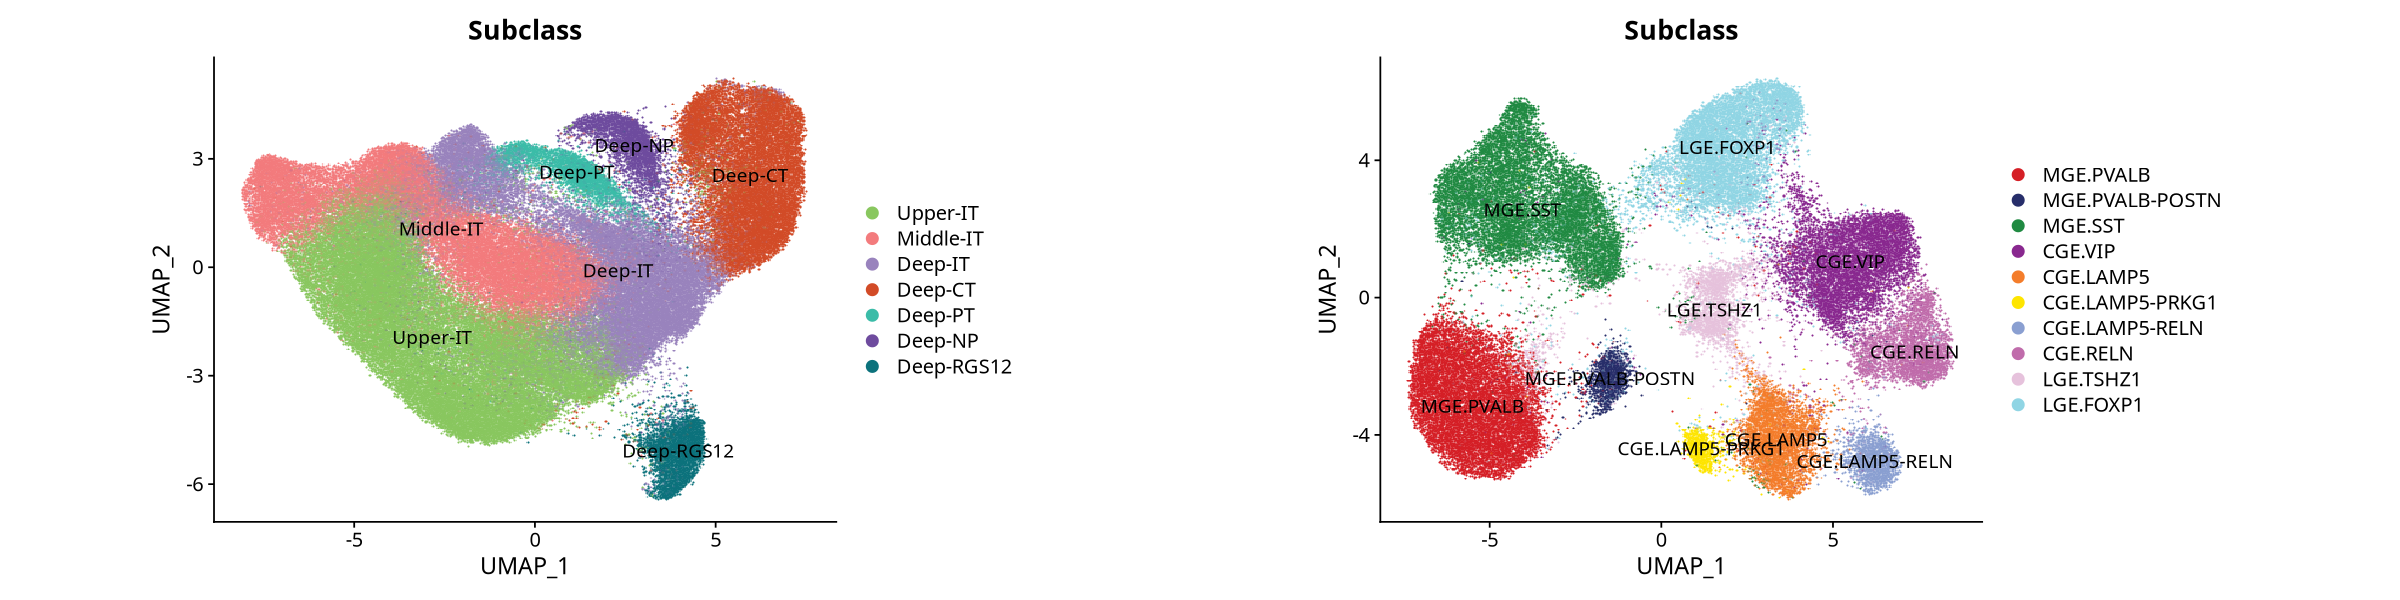

In [ ]:
p1 <- DimPlot(obj_EX,reduction = 'umap',group.by='Subclass',pt.size = 1.5,raster = T,label=T)+
scale_color_manual(values = Subclass_color,breaks = names(Subclass_color))+
coord_fixed()
p2 <- DimPlot(obj_IN,reduction = 'umap',group.by='Subclass',pt.size = 1.5,raster = T,label=T)+
scale_color_manual(values = Subclass_color,breaks = names(Subclass_color))+
coord_fixed()
options(repr.plot.height=5,repr.plot.width=20)
p1|p2

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



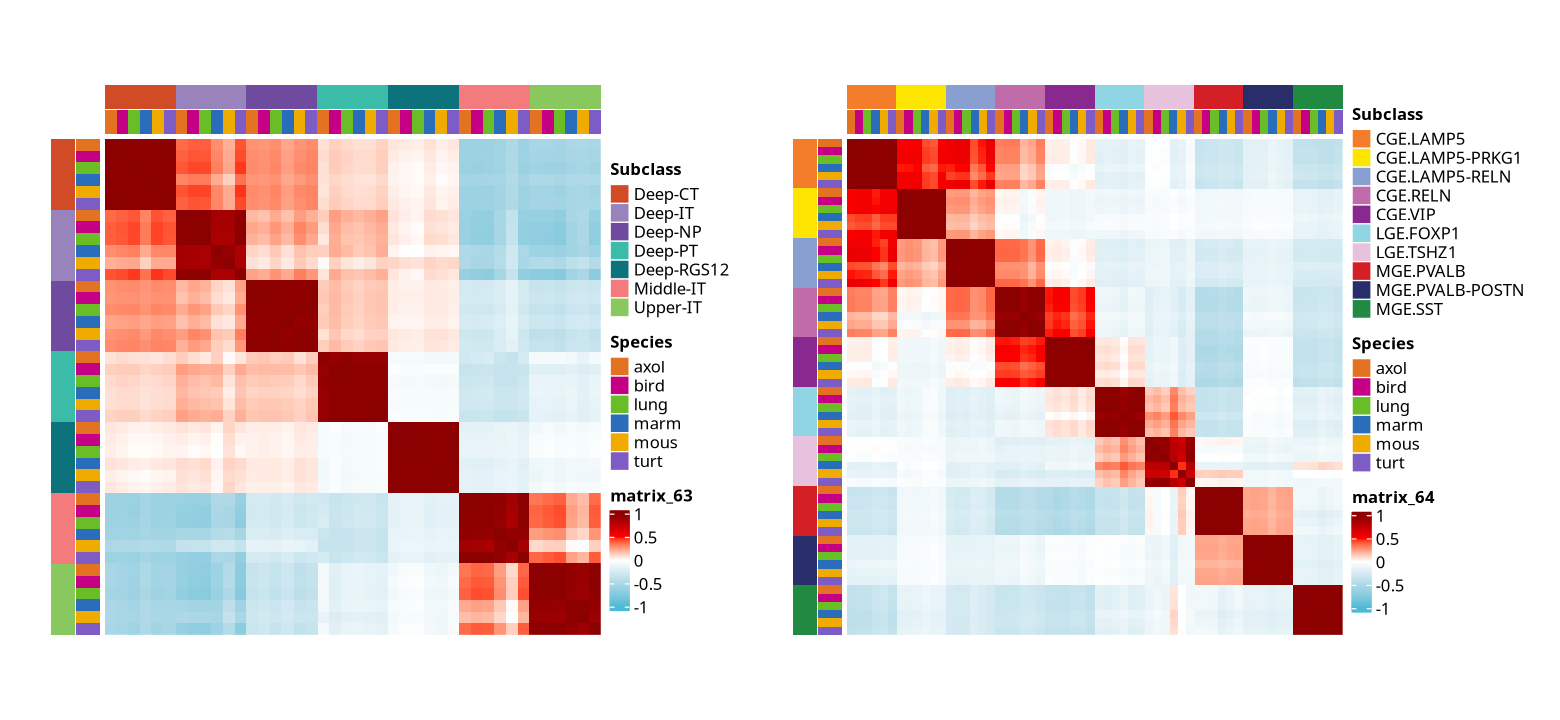

In [ ]:
source('../R_function/calculate_function.R')
Ave_inter_IN <- as.data.frame(t(matrix_groupby(matrix_input = obj_IN@reductions$harmony@cell.embeddings, group.by = paste0(obj_IN$Subclass,'_',obj_IN$species),cal = 'mean', type='row')))
Ave_inter_EX <- as.data.frame(t(matrix_groupby(matrix_input = obj_EX@reductions$harmony@cell.embeddings, group.by = paste0(obj_EX$Subclass,'_',obj_EX$species),cal = 'mean', type='row')))

row_annotation_EX <- rowAnnotation(Subclass = gsub('_.*','',colnames(Ave_inter_EX)),show_annotation_name = FALSE,
                                   Species = gsub('.*_','',colnames(Ave_inter_EX)),
                                   col=list(
                                   Subclass=Subclass_color,
                                   Species=Species_color))
col_annotation_EX <- columnAnnotation(Subclass = gsub('_.*','',colnames(Ave_inter_EX)),show_legend = FALSE,show_annotation_name = FALSE,
                                   Species = gsub('.*_','',colnames(Ave_inter_EX)),
                                   col=list(
                                   Subclass=Subclass_color,
                                   Species=Species_color))

row_annotation_IN <- rowAnnotation(Subclass = gsub('_.*','',colnames(Ave_inter_IN)),show_annotation_name = FALSE,
                                   Species = gsub('.*_','',colnames(Ave_inter_IN)),
                                   col=list(
                                   Subclass=Subclass_color,
                                   Species=Species_color))
col_annotation_IN <- columnAnnotation(Subclass = gsub('_.*','',colnames(Ave_inter_IN)),show_legend = FALSE,show_annotation_name = FALSE,
                                   Species = gsub('.*_','',colnames(Ave_inter_IN)),
                                   col=list(
                                   Subclass=Subclass_color,
                                   Species=Species_color))


p1 <- as.ggplot(ComplexHeatmap::Heatmap(cor(Ave_inter_EX),cluster_rows = F,cluster_columns = F,show_column_names = F,show_row_names = F,
                                        left_annotation = row_annotation_EX,top_annotation = col_annotation_EX,
                                        col = colorRamp2(c(-1,-0.5,0, 0.5, 1), c('#4DBBD5','lightblue','white','red','darkred')),
                                        width =ncol(Ave_inter_EX)*unit(2.5, "mm"),height=ncol(Ave_inter_EX)*unit(2.5, "mm"),use_raster = TRUE
                                       ))
p2 <- as.ggplot(ComplexHeatmap::Heatmap(cor(Ave_inter_IN),cluster_rows = F,cluster_columns = F,show_column_names = F,show_row_names = F,
                                        left_annotation = row_annotation_IN,top_annotation = col_annotation_IN,
                                        col = colorRamp2(c(-1,-0.5,0, 0.5, 1), c('#4DBBD5','lightblue','white','red','darkred')),
                                        width =ncol(Ave_inter_IN)*unit(1.75, "mm"),height=ncol(Ave_inter_IN)*unit(1.75, "mm"),use_raster = TRUE
                                       ))
options(repr.plot.height=6,repr.plot.width=13)
p1|p2

In [ ]:
pdf('Plot/Neuron_correlation_heatmap.pdf',height=6,width=13)
p1|p2
dev.off()

pdf 
  2

pdf 
  2

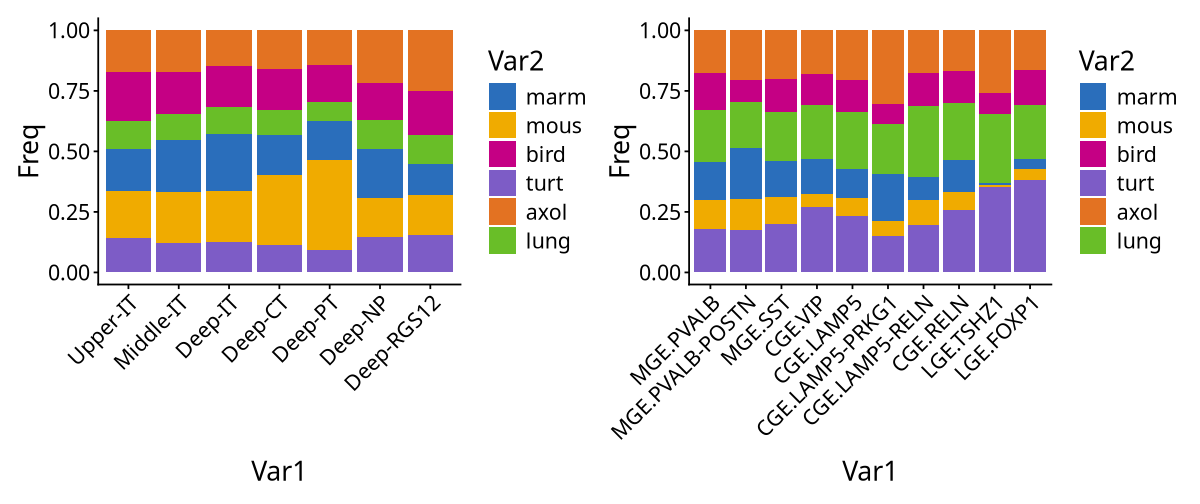

In [ ]:
options(repr.plot.height=4.2,repr.plot.width=10)
p1 <- ggplot()+
geom_bar(data=as.data.frame(table( obj_EX@meta.data$Subclass,as.character(obj_EX@meta.data$species))),aes(x=Var1,y=Freq,fill=Var2),stat='identity',position = 'fill')+
scale_fill_manual(values = Species_color,breaks = names(Species_color))+
#scale_fill_manual(values = Subclass_color,breaks = names(Subclass_color))+
theme_classic()+
theme(text=element_text(size=16),axis.text.x=element_text(angle=45,hjust=1,vjust=1))
p2 <- ggplot()+
geom_bar(data=as.data.frame(table( obj_IN@meta.data$Subclass,as.character(obj_IN@meta.data$species))),aes(x=Var1,y=Freq,fill=Var2),stat='identity',position = 'fill')+
scale_fill_manual(values = Species_color,breaks = names(Species_color))+
#scale_fill_manual(values = Subclass_color,breaks = names(Subclass_color))+
theme_classic()+
theme(text=element_text(size=16),axis.text.x=element_text(angle=45,hjust=1,vjust=1))
p1+p2
pdf('Plot/Neuron_bar_composition.pdf',height=4.2,width=10)
p1+p2
dev.off()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


pdf 
  2

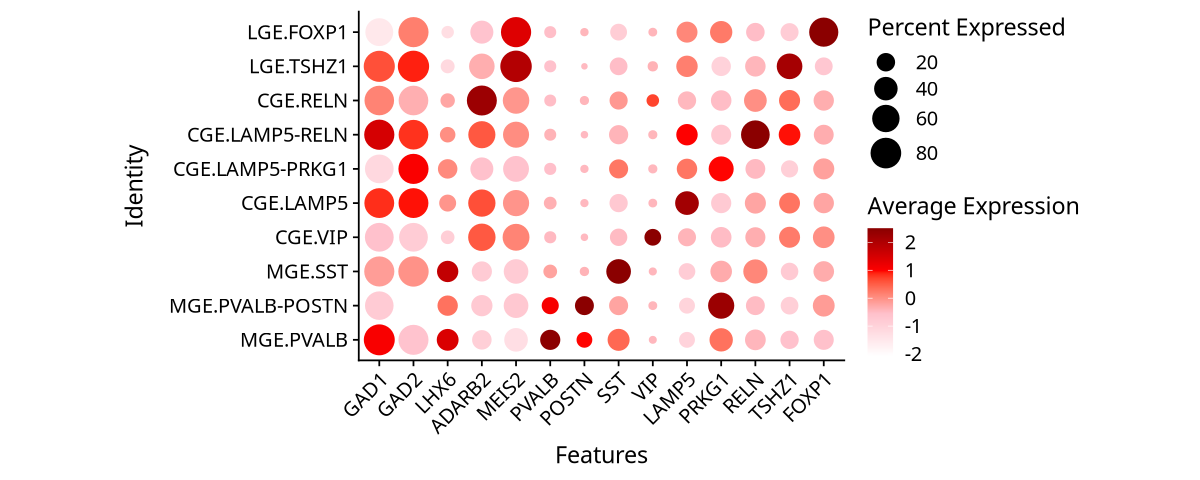

In [ ]:
options(repr.plot.height=4,repr.plot.width=10)
obj_IN@active.assay <- 'RNA'
x_labels <- c('GAD1','GAD2',
              'LHX6','ADARB2', 'MEIS2',
              'PVALB','POSTN','SST',
              'VIP','LAMP5','PRKG1','RELN',
              'TSHZ1','FOXP1')
obj_IN$Subclass <- factor(obj_IN$Subclass, levels = c('MGE.PVALB','MGE.PVALB-POSTN','MGE.SST','CGE.VIP','CGE.LAMP5','CGE.LAMP5-PRKG1','CGE.LAMP5-RELN','CGE.RELN','LGE.TSHZ1','LGE.FOXP1'))
p <- DotPlot(obj_IN,group.by = 'Subclass',features = c('OG0009142','OG0010353',
                                                      'OG0001689','OG0010349','OG0001296',
                                                      'OG0000302','OG0011443','OG0001262',
                                                      'OG0005536','OG0008033','OG0004584','OG0006602',
                                                      'OG0011026','OG0010427'),assay = 'RNA')+
scale_x_discrete(labels= x_labels)+
scale_color_gradientn(colours = c('white','pink','red','darkred'))+
scale_size(range = c(1,8))+
theme(axis.text.x = element_text(angle=45,hjust=1,vjust=1))+
coord_fixed()
p
pdf('Plot/IN_Dotplot_marker.pdf',height=4,width=10)
p
dev.off()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


pdf 
  2

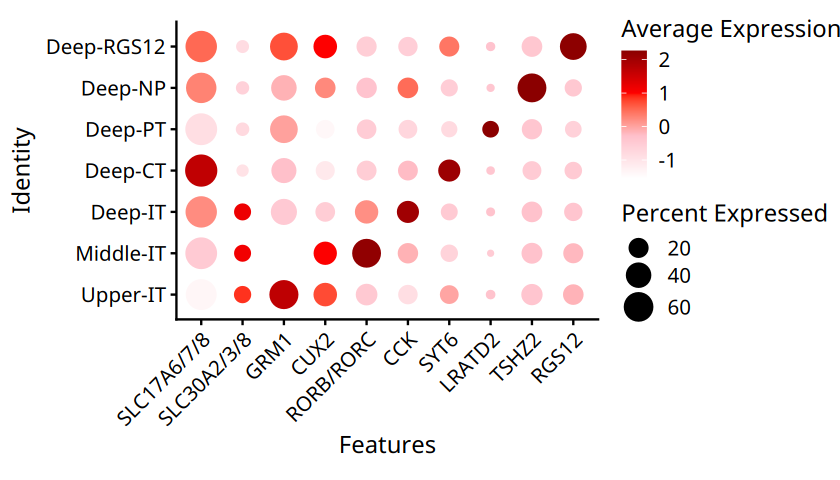

In [14]:
options(repr.plot.height=4,repr.plot.width=7)
x_labels <- c('SLC17A6/7/8',
              'SLC30A2/3/8',
              'GRM1','CUX2',
              'RORB/RORC',
              'CCK',
              'SYT6',
              'LRATD2',
              'TSHZ2',
              'RGS12')
obj_EX$Subclass <- factor(obj_EX$Subclass, levels = c('Upper-IT','Middle-IT','Deep-IT','Deep-CT','Deep-PT','Deep-NP','Deep-RGS12'))

p <- DotPlot(obj_EX,group.by = 'Subclass',features = c('OG0000947',
                                                       'OG0001415',
                                                      'OG0004366','OG0009396',
                                                      'OG0002656',
                                                      'OG0012669',
                                                      'OG0006747',
                                                      'OG0004431',
                                                      'OG0010545',
                                                      'OG0008560'),assay = 'RNA')+
scale_x_discrete(labels= x_labels)+
scale_color_gradientn(colours = c('white','pink','red','darkred'))+
scale_size(range = c(1,8))+
theme(axis.text.x = element_text(angle=45,hjust=1,vjust=1))+
coord_fixed()
p
pdf('Plot/EX_Dotplot_marker.pdf',height=4,width=10)
p
dev.off()

In [ ]:
genelist_marm <- read.csv('/mnt/gandan/lishenglong/mut_sp/data/gene_list/marmoset_og_Pr_Al_region_gene_1026.csv',row.names = 1)
genelist_mous <- read.csv('/mnt/gandan/lishenglong/mut_sp/data/gene_list/mouse_og_Pr_Al_1026.csv',row.names = 1)

genelist_mous$gene <- rownames(genelist_mous)
genelist_marm$gene <- rownames(genelist_marm)

genelist_marm <- genelist_marm[rownames(genelist_marm)%in%c(rownames(obj_EX@assays$integrated),rownames(obj_IN@assays$integrated)),]
genelist_mous <- genelist_mous[rownames(genelist_mous)%in%c(rownames(obj_EX@assays$integrated),rownames(obj_IN@assays$integrated)),]
genelist <- list('marm'=genelist_marm,'mous'=genelist_mous)
saveRDS(genelist,'Analysis/ST_PrAl_OG.rds')

In [ ]:
source('../R_function/knn_function.R')
Add_PrAlscore_integrated <- function(obj_tmp_raw){
    Pr_gene <- intersect(rownames(genelist_marm[order(genelist_marm$cor.cor,decreasing = T),,drop=F])[1:1000],
                         rownames(genelist_mous[order(genelist_mous$cor.cor,decreasing = T),,drop=F])[1:1000])
    Al_gene <- intersect(rownames(genelist_marm[order(genelist_marm$cor.cor,decreasing = F),,drop=F])[1:1000],
                         rownames(genelist_mous[order(genelist_mous$cor.cor,decreasing = F),,drop=F])[1:1000])
    obj_tmp_raw@active.assay <- 'integrated'
    #obj_tmp <- ScaleData(obj_tmp,features = c(Pr_gene,Al_gene))
    obj_tmp_raw <- AddModuleScore(obj_tmp_raw,features = list('Pr'=Pr_gene,'Al'=Al_gene),assay = 'integrated',slot='data',seed = 0)
    obj_tmp_raw@meta.data <- obj_tmp_raw@meta.data[,!colnames(obj_tmp_raw@meta.data)%in%c('Pr_score','Al_score')]
    colnames(obj_tmp_raw@meta.data)[colnames(obj_tmp_raw@meta.data)=='Cluster1'] <- 'Pr_score'
    colnames(obj_tmp_raw@meta.data)[colnames(obj_tmp_raw@meta.data)=='Cluster2'] <- 'Al_score'
    obj_tmp_raw@meta.data$species <- factor(obj_tmp_raw@meta.data$species,levels = c('marm','mous','bird','turt','axol','lung','lamp'))

    source('../R_function/knn_function.R')
    knn <- 25
    cell_sample <- seq(1,nrow(obj_tmp_raw@meta.data),length.out = 50000)
    obj_tmp_raw$Pr_score_smooth <- NA
    obj_tmp_raw$Al_score_smooth <- NA
    obj_tmp_raw@meta.data[cell_sample,'Pr_score_smooth'] <- magic_knn(smooth_df = obj_tmp_raw@reductions$harmony@cell.embeddings[cell_sample,1:15],
                                      sm_vector = obj_tmp_raw@meta.data[cell_sample,'Pr_score'],
                                      knn = knn, round = 3)
    gc()
    obj_tmp_raw@meta.data[cell_sample,'Al_score_smooth'] <- magic_knn(smooth_df = obj_tmp_raw@reductions$harmony@cell.embeddings[cell_sample,1:15],
                                              sm_vector = obj_tmp_raw@meta.data[cell_sample,'Al_score'],
                                              knn = knn, round = 3)
    gc()
    obj_tmp_raw@meta.data[is.na(obj_tmp_raw@meta.data[,'Pr_score_smooth']),'Pr_score_smooth'] <- smooth_kNN2(initial_df = obj_tmp_raw@reductions$harmony@cell.embeddings[!is.na(obj_tmp_raw@meta.data[,'Pr_score_smooth']),1:15],
                                                                                       query_df = obj_tmp_raw@reductions$harmony@cell.embeddings[is.na(obj_tmp_raw@meta.data[,'Pr_score_smooth']),1:15],
                                      sm_vector = obj_tmp_raw@meta.data[!is.na(obj_tmp_raw@meta.data[,'Pr_score_smooth']),'Pr_score_smooth'],
                                      knn = knn, round = 1)
    gc()
    obj_tmp_raw@meta.data[is.na(obj_tmp_raw@meta.data[,'Al_score_smooth']),'Al_score_smooth'] <- smooth_kNN2(initial_df = obj_tmp_raw@reductions$harmony@cell.embeddings[!is.na(obj_tmp_raw@meta.data[,'Al_score_smooth']),1:15],
                                                                                       query_df = obj_tmp_raw@reductions$harmony@cell.embeddings[is.na(obj_tmp_raw@meta.data[,'Al_score_smooth']),1:15],
                                      sm_vector = obj_tmp_raw@meta.data[!is.na(obj_tmp_raw@meta.data[,'Al_score_smooth']),'Al_score_smooth'],
                                      knn = knn, round = 1)
    obj_tmp_raw$Pr_score <- obj_tmp_raw$Pr_score_smooth
    obj_tmp_raw$Al_score <- obj_tmp_raw$Al_score_smooth
    obj_tmp_raw@meta.data <- obj_tmp_raw@meta.data[,!colnames(obj_tmp_raw@meta.data)%in%c('Pr_score_smooth','Al_score_smooth')]
    return(obj_tmp_raw)
    }

Normalize_PrAl_score <- function(obj_tmp_raw,df_score_species,norm_function='subclass',norm_group='species'){
    if(norm_group=='species'){
    for(i in unique(df_score_species$species)){
        df_score_tmp <- df_score_species[df_score_species$species==i,]
        df_score_tmp$Pr_score <- df_score_tmp$Pr_score_species
        df_score_tmp$Al_score <- df_score_tmp$Al_score_species

        if(norm_function=='subclass'){
            #use subclasss normalize
            df_score_tmp <- dplyr::bind_rows(lapply(unique(df_score_tmp$Subclass),function(subclass){
                df_tmp <- df_score_tmp[df_score_tmp$Subclass==subclass,]
                df_tmp$Pr_score_middle <- df_tmp$Pr_score-(max(df_tmp$Pr_score)+min(df_tmp$Pr_score))/2
                df_tmp$Al_score_middle <- df_tmp$Al_score-(max(df_tmp$Al_score)+min(df_tmp$Al_score))/2
                return(df_tmp)}))
        }else if(norm_function=='subclass_norm'){   
            #use subclasss normalize
            df_score_tmp <- dplyr::bind_rows(lapply(unique(df_score_tmp$Subclass),function(subclass){
                df_tmp <- df_score_tmp[df_score_tmp$Subclass==subclass,]
                df_tmp$Pr_score_middle <- (df_tmp$Pr_score-min(df_tmp$Pr_score))/(max(df_tmp$Pr_score)-min(df_tmp$Pr_score))
                df_tmp$Al_score_middle <- (df_tmp$Al_score-min(df_tmp$Al_score))/(max(df_tmp$Al_score)-min(df_tmp$Al_score))
                return(df_tmp)}))
            
        }else if(norm_function=='all'){   
            #use all normalize
            df_score_tmp$Pr_score_middle <- (df_score_tmp$Pr_score-min(df_score_tmp$Pr_score))/(max(df_score_tmp$Pr_score)-min(df_score_tmp$Pr_score))
            df_score_tmp$Al_score_middle <- (df_score_tmp$Al_score-min(df_score_tmp$Al_score))/(max(df_score_tmp$Al_score)-min(df_score_tmp$Al_score))
        }
        df_score_tmp$Pr_Al_Index <- (df_score_tmp$Pr_score_middle - df_score_tmp$Al_score_middle)/((1-df_score_tmp$Pr_score_middle)+(1-df_score_tmp$Al_score_middle))
        obj_tmp_raw@meta.data[,paste0('Pr_score_',i)] <- df_score_tmp[colnames(obj_tmp_raw),'Pr_score_middle']
        obj_tmp_raw@meta.data[,paste0('Al_score_',i)] <- df_score_tmp[colnames(obj_tmp_raw),'Al_score_middle']
        obj_tmp_raw@meta.data[,paste0('Pr_Al_Index_',i)] <- df_score_tmp[colnames(obj_tmp_raw),'Pr_Al_Index']
    }}
        
    #obj_tmp_raw@meta.data$species <- factor(obj_tmp_raw@meta.data$species,levels = c('marm','mous','bird','turt','axol','lung','lamp'))
    return(obj_tmp_raw)
    }

In [ ]:
source('../R_function/mutimodal.R')

In [ ]:
obj_EX <- Add_PrAlscore_integrated(obj_EX)
obj_IN <- Add_PrAlscore_integrated(obj_IN)

Warning message:
“The following features are not present in the object: OG0002726, OG0003094, OG0000868, OG0010990, OG0006364, OG0007632, OG0001267, OG0000644, OG0000957, OG0005305, OG0006463, OG0005033, OG0005354, OG0000843, OG0000213, OG0002180, OG0001595, OG0009927, OG0003795, OG0001756, OG0001999, OG0001874, OG0001768, OG0000293, OG0001182, OG0000835, OG0009148, OG0001706, OG0002046, OG0002574, OG0010599, OG0001721, OG0007040, OG0009745, OG0002480, OG0001741, OG0001313, OG0010566, OG0009651, OG0010624, OG0009189, OG0000803, OG0001360, OG0000907, OG0005348, OG0011463, OG0001256, OG0002486, OG0004792, OG0011095, OG0004402, OG0003308, OG0002070, OG0001789, OG0000536, OG0001148, OG0006708, OG0001784, OG0002980, OG0007617, OG0004901, OG0000658, OG0005041, OG0001505, OG0000393, OG0011092, OG0005611, OG0008772, OG0002510, OG0001850, OG0003695, OG0005331, OG0010742, OG0008693, OG0002719, OG0003293, OG0006413, OG0011687, OG0012452, OG0002142, OG0000511, OG0001316, OG0001395, OG0006530, OG00

In [ ]:
obj_EX <- Normalize_PrAl_score(obj_EX,df_score_species_EX,norm_function='all')
obj_IN <- Normalize_PrAl_score(obj_IN,df_score_species_IN,norm_function='all')

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


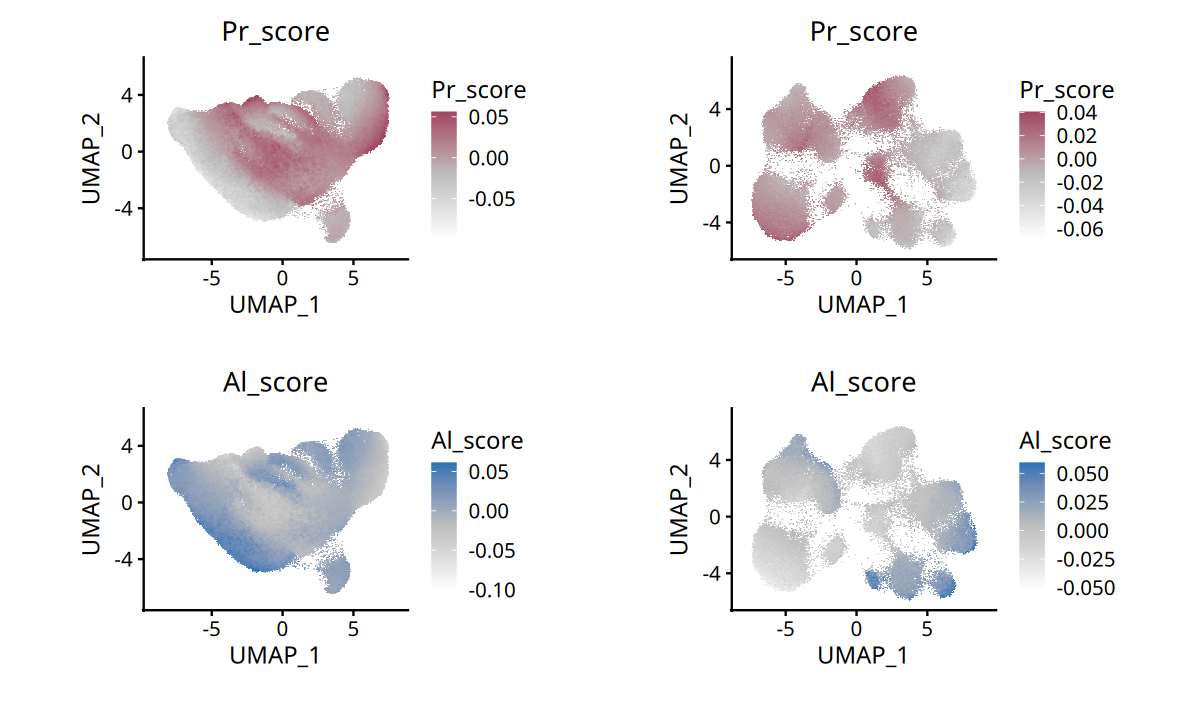

In [ ]:
p1 <- FeaturePlot(obj_EX,features = c('Pr_score'),max.cutoff = 'q99',raster = T,pt.size = 2)+
scale_color_gradientn(colours = c('white','gray','#A14462'),name = 'Pr_score')+
coord_fixed()
p2 <- FeaturePlot(obj_EX,features = c('Al_score'),max.cutoff = 'q99',raster = T,pt.size = 2)+
scale_color_gradientn(colours = c('white','gray','#2873B3'),name = 'Al_score')+
coord_fixed()
p3 <- FeaturePlot(obj_IN,features = c('Pr_score'),max.cutoff = 'q99',col=c('#A14462','#2873B3'),raster = T,pt.size = 2)+
scale_color_gradientn(colours = c('white','gray','#A14462'),name = 'Pr_score')+
coord_fixed()
p4 <- FeaturePlot(obj_IN,features = c('Al_score'),max.cutoff = 'q99',col=c('#A14462','#2873B3'),raster = T,pt.size = 2)+
scale_color_gradientn(colours = c('white','gray','#2873B3'),name = 'Al_score')+
coord_fixed()
options(repr.plot.width=10,repr.plot.height=6)
(p1/p2)|(p3/p4)
pdf('Plot/Neuron_UMAP_Pr_and_Al_score.pdf',height=6,width=15)
(p1/p2)|(p3/p4)
dev.off()

In [ ]:
source('../R_function/Pr_Al.R')

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


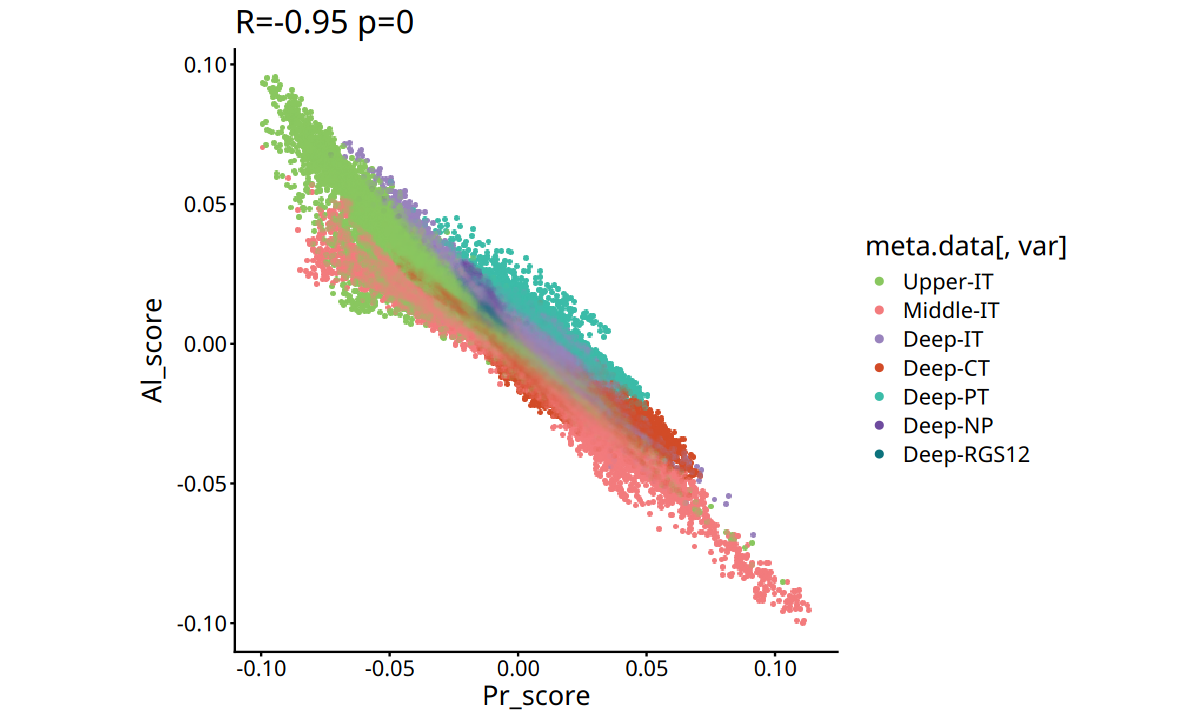

In [ ]:
plot_cor_raster(obj_EX@meta.data,X ='Pr_score',Y='Al_score',var = 'Subclass')+
scale_color_manual(values = Subclass_color,breaks = names(Subclass_color))

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


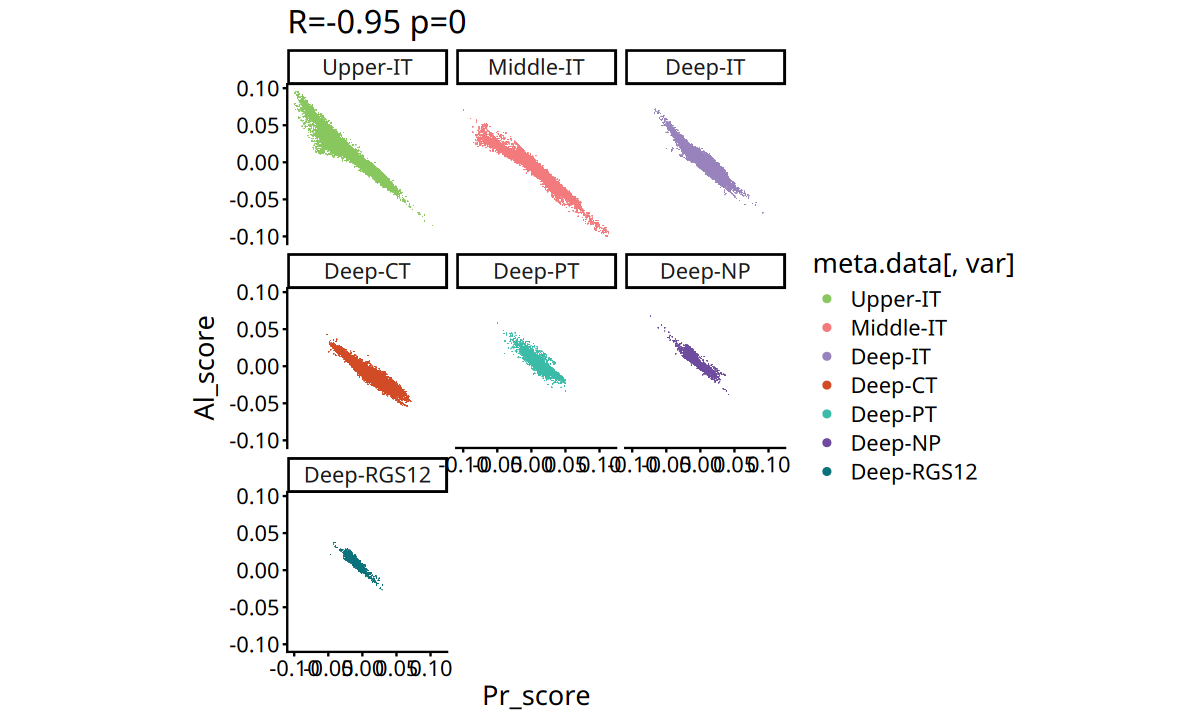

In [ ]:
plot_cor_raster(obj_EX@meta.data,X ='Pr_score',Y='Al_score',var = 'Subclass')+
facet_wrap(~Subclass)+
scale_color_manual(values = Subclass_color,breaks = names(Subclass_color))

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


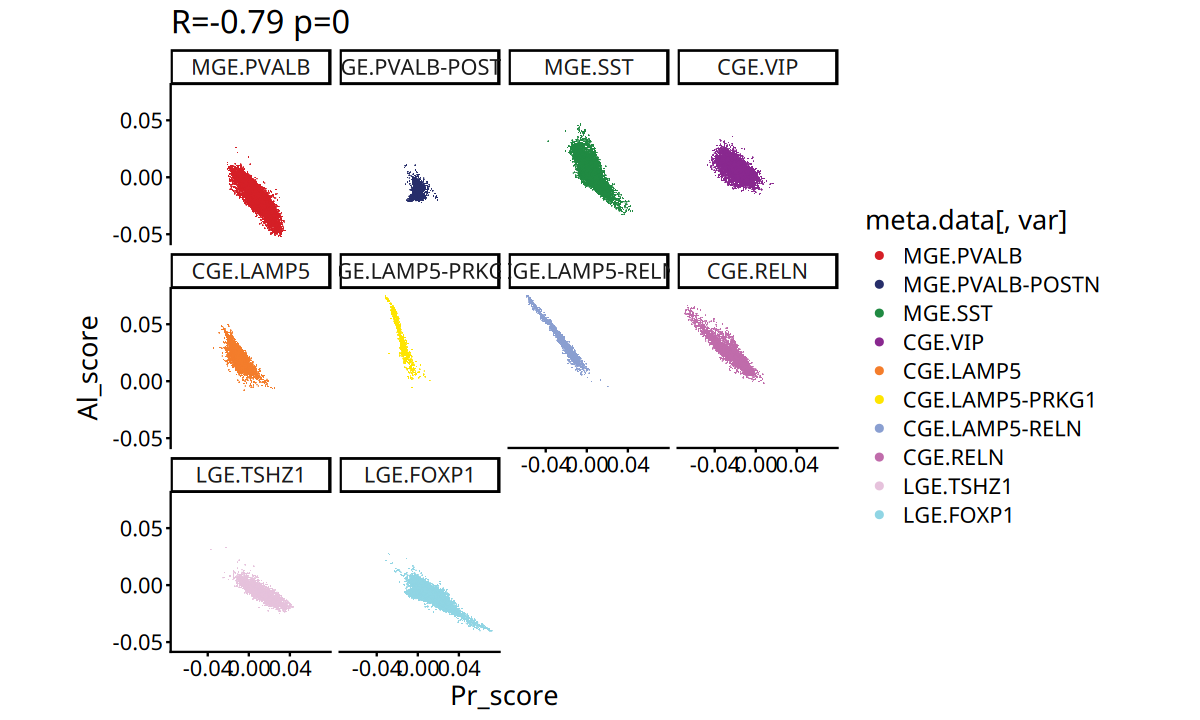

In [ ]:
plot_cor_raster(obj_IN@meta.data,X ='Pr_score',Y='Al_score',var = 'Subclass')+
facet_wrap(~Subclass)+
scale_color_manual(values = Subclass_color,breaks = names(Subclass_color))

In [ ]:
trim_df <- function(df,trim_column,max_cut=0.99,min_cut=0.01){
    max_cut <- quantile(df[,trim_column],max_cut)
    min_cut <- quantile(df[,trim_column],min_cut)
    df[df[,trim_column] > max_cut, trim_column] <- max_cut
    df[df[,trim_column] < min_cut, trim_column] <- min_cut
    return(df[,trim_column])
}
equal_split <- function(input_vector){
    
}

In [ ]:
numeric_vector_group <- function(vec, n_groups) {
  n_groups <- as.integer(n_groups)
  if (length(vec) < n_groups) stop("")

  quantiles <- quantile(vec, probs = seq(0, 1, length.out = n_groups + 1), na.rm = TRUE)
  groups <- cut(vec, breaks = quantiles, include.lowest = TRUE, labels = FALSE)
  group_means <- tapply(vec, groups, mean, na.rm = TRUE)
  group_names <- round(group_means, 2)
  groups_named <- factor(groups, levels = 1:n_groups, labels = group_names)
  return(as.numeric(levels(groups_named))[groups])
}

In [ ]:
obj_EX_Pr_score <- trim_df(obj_EX@meta.data,'Pr_score',max_cut=1,min_cut=0)
obj_EX_Al_score <- trim_df(obj_EX@meta.data,'Al_score',max_cut=1,min_cut=0)
obj_EX@meta.data$Pr_score_norm <- (obj_EX_Pr_score - min(obj_EX_Pr_score))/(max(obj_EX_Pr_score)-min(obj_EX_Pr_score))
obj_EX@meta.data$Al_score_norm <- (obj_EX_Al_score - min(obj_EX_Al_score))/(max(obj_EX_Al_score)-min(obj_EX_Al_score))
obj_EX@meta.data$`Pr-Al-Index` <- (obj_EX$Pr_score_norm - obj_EX$Al_score_norm)/((1-obj_EX$Pr_score_norm)+(1-obj_EX$Al_score_norm))
obj_EX@meta.data$type <- 'Other'
obj_EX@meta.data[obj_EX@meta.data$`Pr-Al-Index` > 0.1,]$type <- 'Pr'
obj_EX@meta.data[obj_EX@meta.data$`Pr-Al-Index` < -0.1,]$type <- 'Al'
obj_EX@meta.data$`Pr-Al-Type` <- numeric_vector_group(obj_EX@meta.data$`Pr-Al-Index`,10)

In [ ]:
obj_IN_Pr_score <- trim_df(obj_IN@meta.data,'Pr_score',max_cut=1,min_cut=0)
obj_IN_Al_score <- trim_df(obj_IN@meta.data,'Al_score',max_cut=1,min_cut=0)
obj_IN@meta.data$Pr_score_norm <- (obj_IN_Pr_score - min(obj_IN_Pr_score))/(max(obj_IN_Pr_score)-min(obj_IN_Pr_score))
obj_IN@meta.data$Al_score_norm <- (obj_IN_Al_score - min(obj_IN_Al_score))/(max(obj_IN_Al_score)-min(obj_IN_Al_score))
obj_IN@meta.data$`Pr-Al-Index` <- (obj_IN$Pr_score_norm - obj_IN$Al_score_norm)/((1-obj_IN$Pr_score_norm)+(1-obj_IN$Al_score_norm))
obj_IN@meta.data$type <- 'Other'
obj_IN@meta.data[obj_IN@meta.data$`Pr-Al-Index` > 0.1,]$type <- 'Pr'
obj_IN@meta.data[obj_IN@meta.data$`Pr-Al-Index` < -0.1,]$type <- 'Al'
obj_IN@meta.data$`Pr-Al-Type` <- numeric_vector_group(obj_IN@meta.data$`Pr-Al-Index`,10)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


pdf 
  2

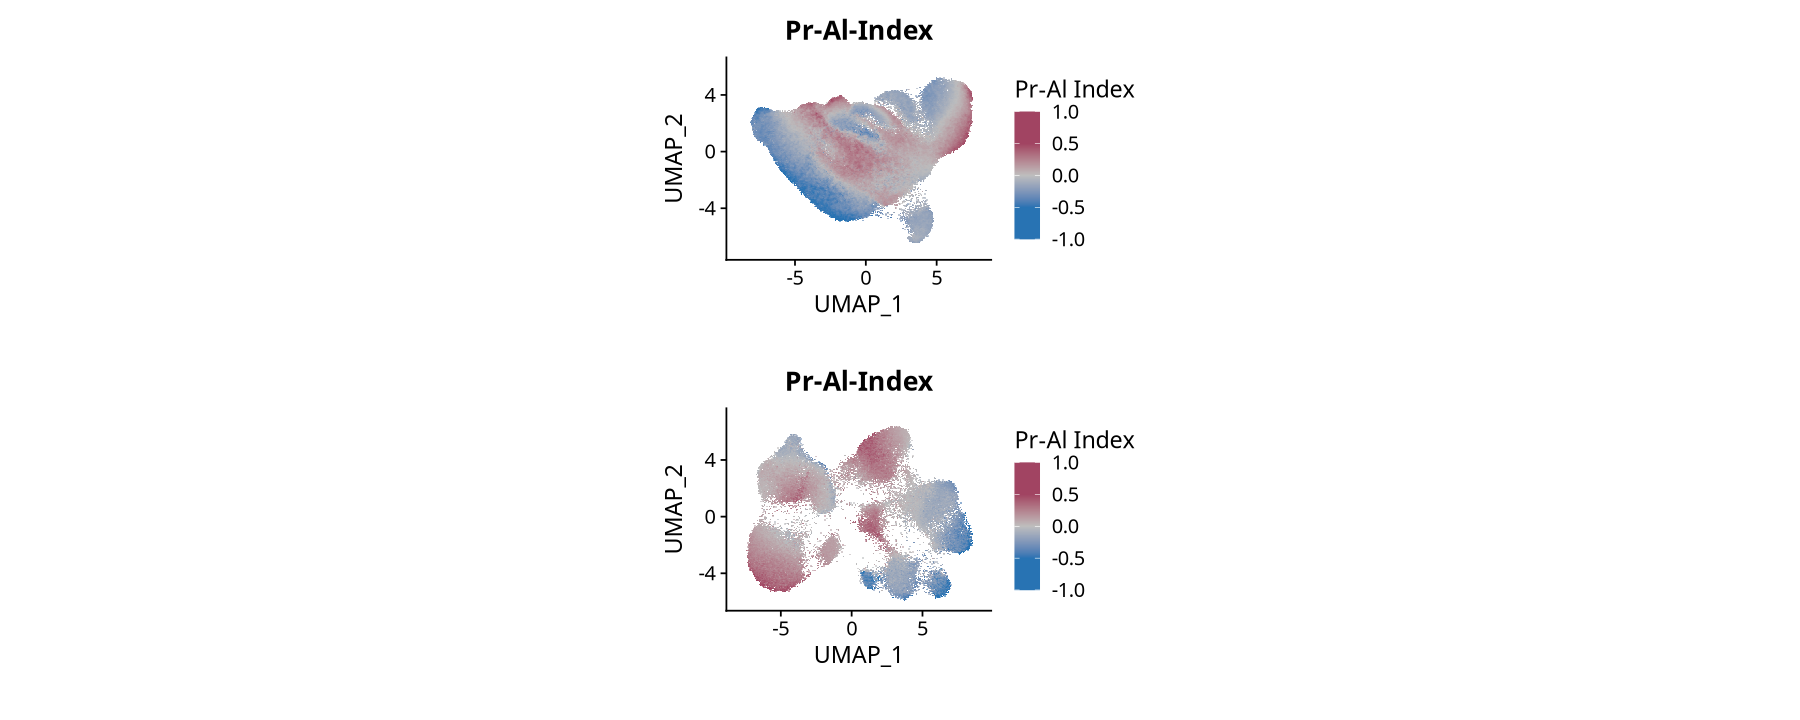

In [ ]:
p1 <- FeaturePlot(obj_EX,features = c('Pr-Al-Index'),raster = T,pt.size = 2)+
scale_color_gradientn(colours = c('#2873B3','#2873B3','gray','#A14462','#A14462'),name = 'Pr-Al Index')+
coord_fixed()
p2 <- FeaturePlot(obj_IN,features = c('Pr-Al-Index'),raster = T,pt.size = 2)+
scale_color_gradientn(colours = c('#2873B3','#2873B3','gray','#A14462','#A14462'),name = 'Pr-Al Index')+
coord_fixed()
options(repr.plot.width=15,repr.plot.height=6)
p1/p2

pdf('Plot/Neuron_UMAP_Pr_Al_Index.pdf',height=6,width=15)
p1/p2
dev.off()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is

pdf 
  2

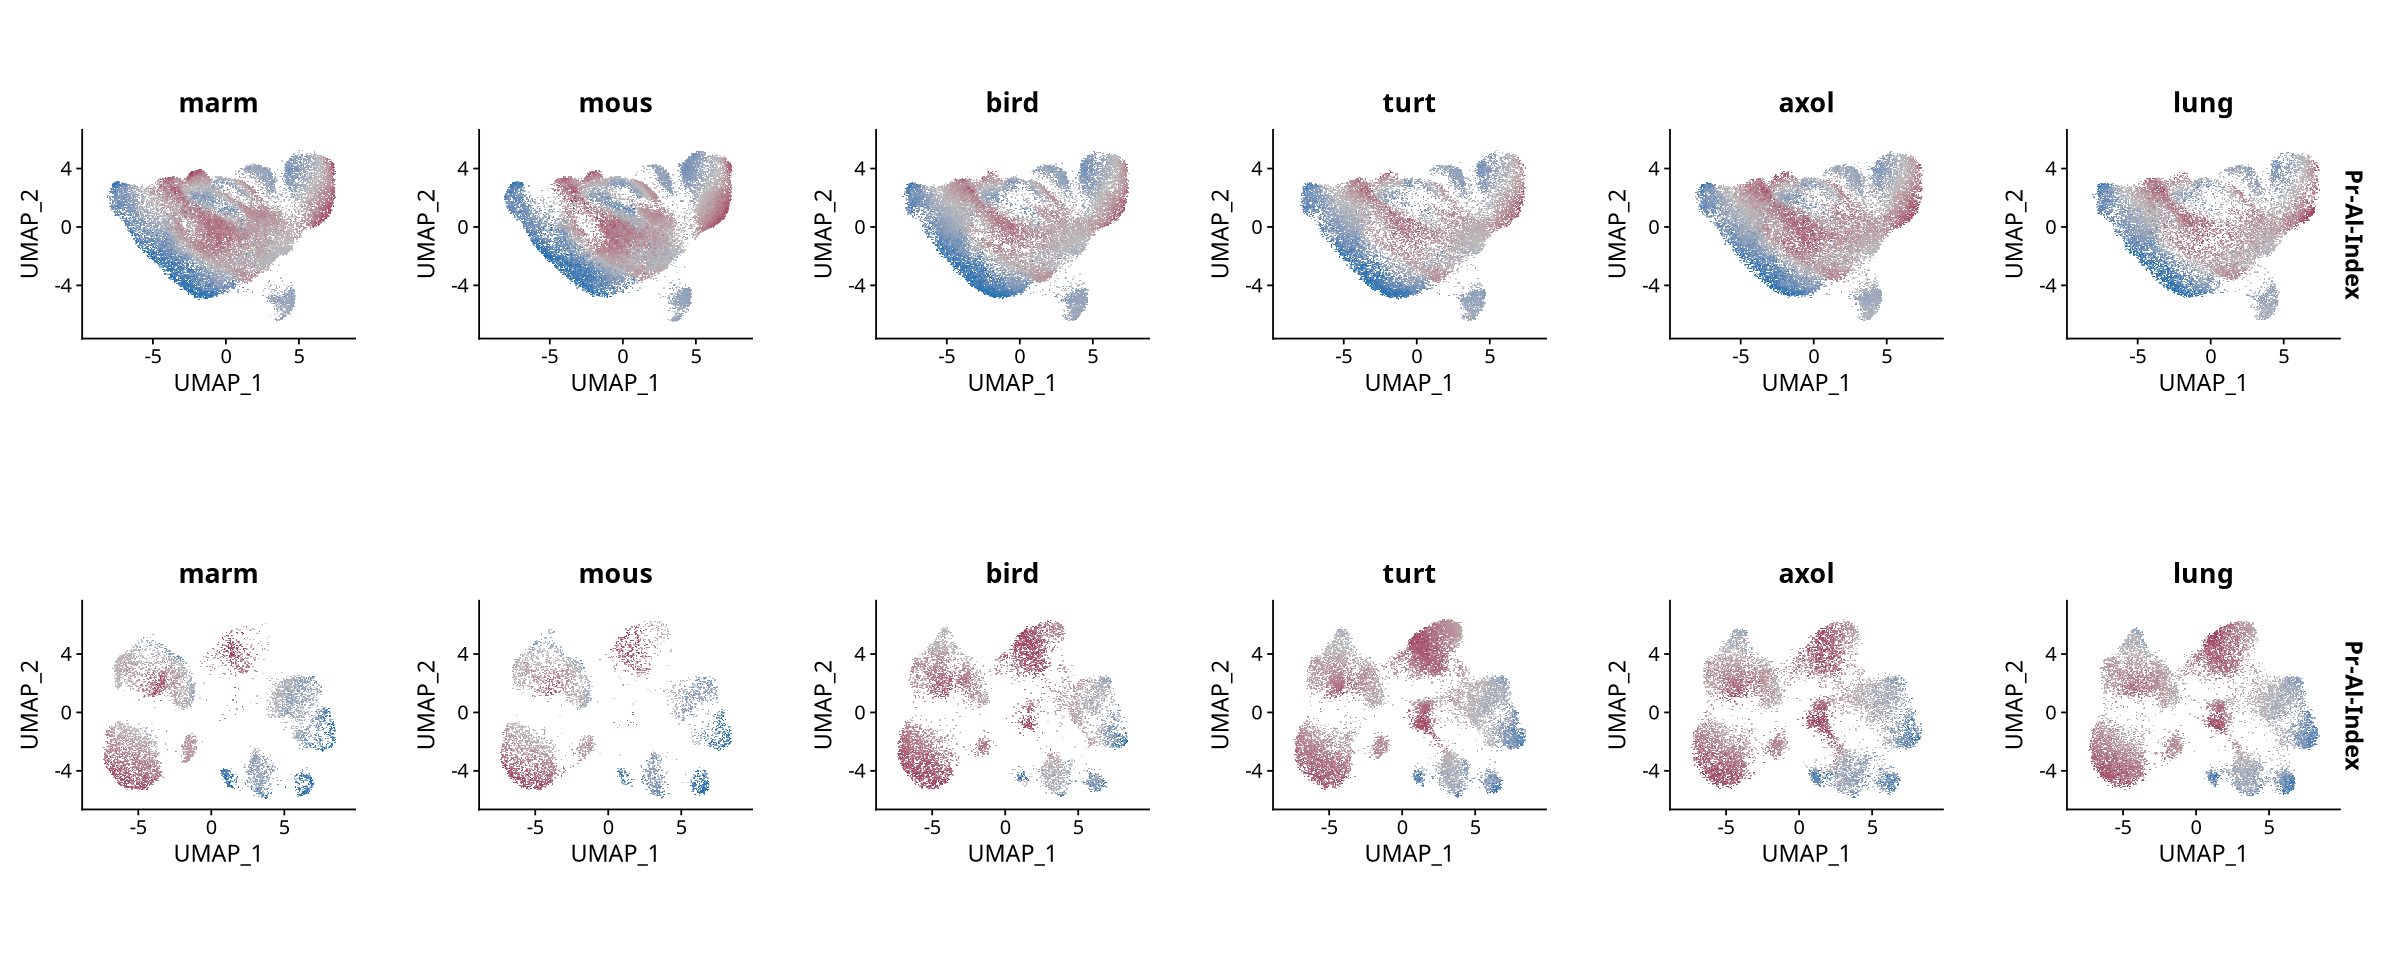

In [ ]:
p1 <- FeaturePlot(obj_EX,features = c('Pr-Al-Index'),split.by = 'species',raster = T,pt.size = 2)&
scale_color_gradientn(colours = c('#2873B3','#2873B3','gray','#A14462','#A14462'),name = 'Pr-Al Index')&
coord_fixed()
p2 <- FeaturePlot(obj_IN,features = c('Pr-Al-Index'),split.by = 'species',raster = T,pt.size = 2)&
scale_color_gradientn(colours = c('#2873B3','#2873B3','gray','#A14462','#A14462'),name = 'Pr-Al Index')&
coord_fixed()
options(repr.plot.width=20,repr.plot.height=8)
p1/p2
pdf('Plot/Neuron_Species_UMAP_Pr_Al_Index.pdf',width=20,height=8)
p1/p2
dev.off()

In [ ]:
table(obj_EX$`Pr-Al-Type`)


-0.44 -0.27 -0.18 -0.11 -0.04  0.02  0.07  0.12  0.18  0.31 
13435 13434 13434 13434 13434 13435 13433 13434 13434 13435 

In [ ]:
table(obj_IN$`Pr-Al-Type`)


-0.38 -0.17 -0.08 -0.01  0.05   0.1  0.15   0.2  0.27  0.41 
 5739  5739  5738  5739  5738  5739  5738  5739  5738  5739 

In [ ]:
y_split <- sapply(unique(df_tmp$`Pr-Al-Type`),function(x){
    PrAl_type_df <- df_tmp[df_tmp$`Pr-Al-Type`==x,]
    return(min(PrAl_type_df$`Pr-Al-Index`))})
y_split <- unique(unlist(y_split))
y_split <- c(y_split,1)

In [ ]:
plot_quasirandom <- function(meta.data,X,Y,X_group=NULL,group_down=TRUE,group_size=500,y_dashed=c(0),raster=FALSE,split=FALSE){
    set.seed(123)
    df_tmp <- meta.data
    if(split){
        y_split <- sapply(unique(df_tmp$`Pr-Al-Type`),function(x){
            PrAl_type_df <- df_tmp[df_tmp$`Pr-Al-Type`==x,]
            return(min(PrAl_type_df$`Pr-Al-Index`))})
        y_split <- unique(unlist(y_split))
        y_split <- c(y_split,1)}
    
    if(group_down){
        df_tmp <- dplyr::bind_rows(lapply(unique(df_tmp[,X]),function(x){
            group_df <- df_tmp[df_tmp[,X]==x,]
            return(group_df[sample(rownames(group_df),size = group_size),])}))}
    df_tmp$group <- df_tmp[,X]
    df_tmp$value <- df_tmp[,Y]
    df_tmp$X_group <- df_tmp[,X_group]

    p <- ggplot(data=df_tmp)
    if(raster){
        if(is.null(X_group)){
            p <- p+geom_quasirandom_rast( aes(x = group, y = value,color=value),dodge.width = 0.9,size=0.5)
        }else{
            p <- p+geom_quasirandom_rast( aes(x = group, y = value,color=value,group=X_group),dodge.width = 0.9,size=0.5)
        }
    }else{
        if(is.null(X_group)){
            p <- p+geom_quasirandom( aes(x = group, y = value,color=value),dodge.width = 0.9,size=0.5)
        }else{
            p <- p+geom_quasirandom( aes(x = group, y = value,color=value,group=X_group),dodge.width = 0.9,size=0.5)
        }
    }
    p <- p+
    scale_color_gradientn(colours  = c('#2873B3','#2873B3','gray','#A14462','#A14462'),limits=c(-1,1),name = X)+
    theme_classic()+
    theme(axis.text.x=element_text(angle=45,hjust=1,vjust = 1))+
    NoLegend()+
    ylim(-1,1)+
    ylab(Y)+
    xlab(X)
    p <- p+geom_hline(yintercept = y_dashed,linetype='dashed')
    return(p)
}

In [ ]:
source('../R_function/plot_function.R')

In [ ]:
p1 <- plot_quasirandom(obj_EX@meta.data,X='Subclass',Y='Pr-Al-Index',X_group='species',group_down=FALSE,raster=TRUE)
p2 <- plot_quasirandom(obj_IN@meta.data,X='Subclass',Y='Pr-Al-Index',X_group='species',group_down=FALSE,raster=TRUE)

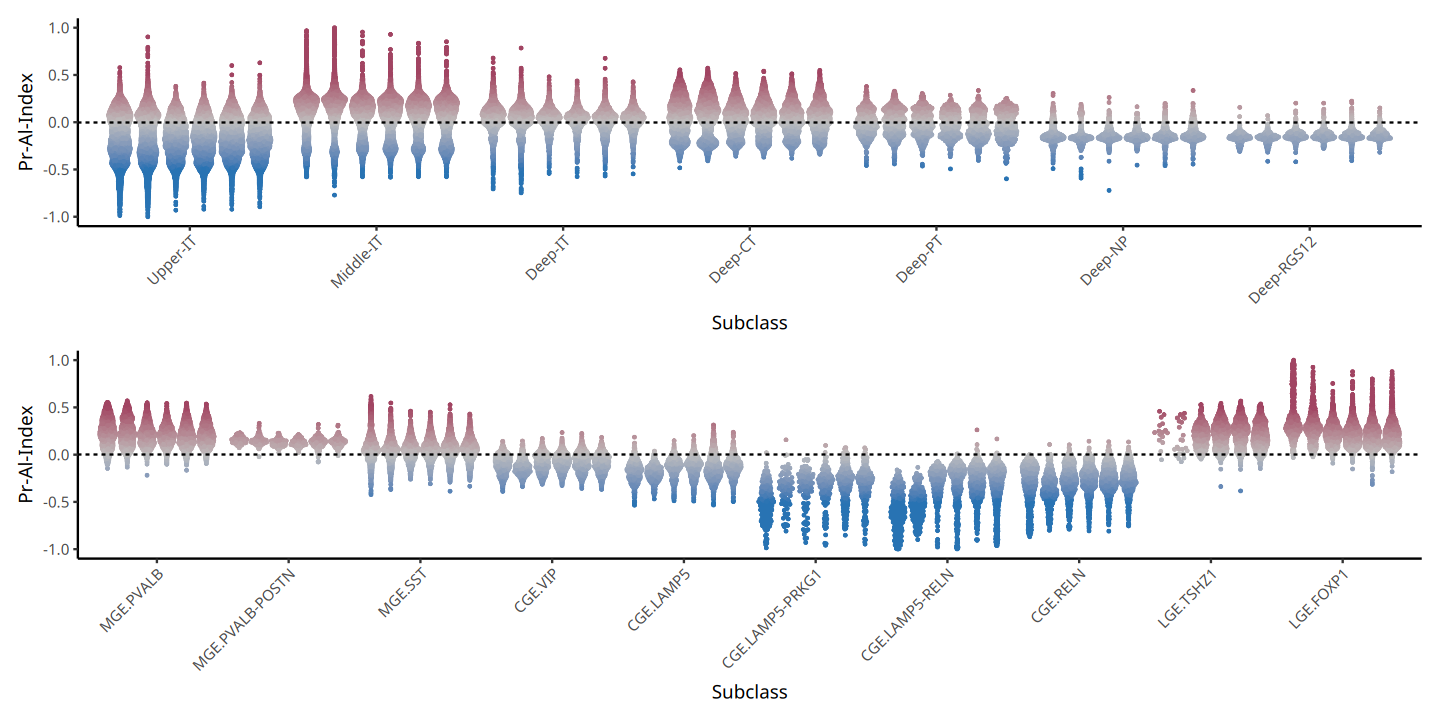

In [ ]:
options(repr.plot.width=12,repr.plot.height=6)
p1/p2

In [ ]:
pdf('Plot/Neuron_Species_quasirandom_Pr_Al_Index.pdf',width=12,height=6)
p1/p2
dev.off()

pdf 
  2

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


pdf 
  2

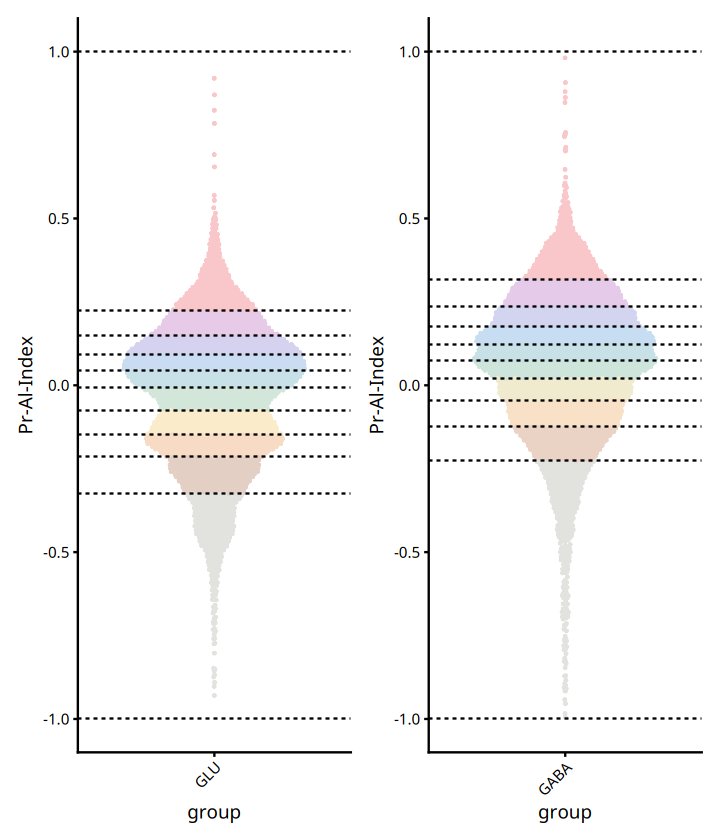

In [ ]:
df1 <- obj_EX@meta.data
#df1$`Pr-Al-Type` <- as.character(df1$`Pr-Al-Type`)
df1$Neuron <- 'GLU'
df2 <- obj_IN@meta.data
#df2$`Pr-Al-Type` <- as.character(df2$`Pr-Al-Type`)
df2$Neuron <- 'GABA'
p1 <- plot_quasirandom(df1,'Neuron',5000,split=TRUE)+scale_color_gradientn(colours  = c("#e2e2df","#d2d2cf","#e2cfc4","#f7d9c4","#faedcb","#c9e4de","#c6def1","#dbcdf0","#f2c6de","#f9c6c9"))
p2 <- plot_quasirandom(df2,'Neuron',5000,split=TRUE)+scale_color_gradientn( colours = c("#e2e2df","#d2d2cf","#e2cfc4","#f7d9c4","#faedcb","#c9e4de","#c6def1","#dbcdf0","#f2c6de","#f9c6c9"))
options(repr.plot.width=6,repr.plot.height=7)
p1|p2
pdf('Plot/Neuron_quasirandom_Pr_Al_Index_class_split.pdf',height=7,width=6)
p1|p2
dev.off()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


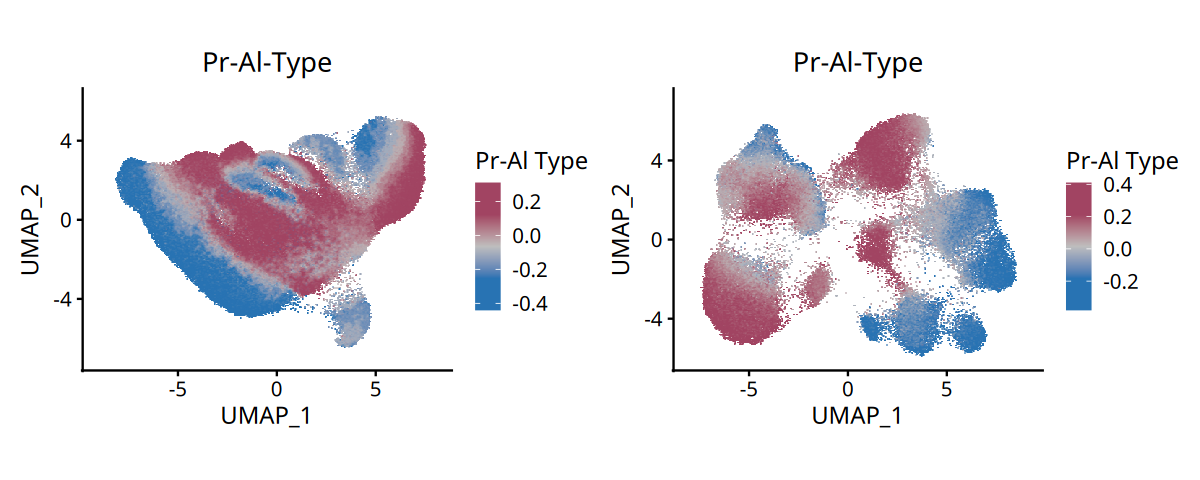

In [ ]:
p1 <- FeaturePlot(obj_EX,features = c('Pr-Al-Type'),raster = T,pt.size = 2)+
scale_color_gradientn(colours  = c('#2873B3','#2873B3','gray','#A14462','#A14462'),name = 'Pr-Al Type')+
coord_fixed()
p2 <-  FeaturePlot(obj_IN,features = c('Pr-Al-Type'),raster = T,pt.size = 2)+
scale_color_gradientn(colours = c('#2873B3','#2873B3','gray','#A14462','#A14462'),name = 'Pr-Al Type')+
coord_fixed()
options(repr.plot.width=10,repr.plot.height=4)
p1|p2

In [ ]:
obj_EX@active.assay <- 'RNA'
obj_IN@active.assay <- 'RNA'

In [ ]:
save_seurat_key(obj_EX,path = 'Analysis/obj_GLU_integrated_final_20260206_keys.rds')
save_seurat_key(obj_IN,path = 'Analysis/obj_GABA_integrated_final_20260206_keys.rds')

In [ ]:
PrAl_gene_ae_EX_Subclass <- as.data.frame(AverageExpression(obj_EX,group.by = c('species','Subclass','Pr-Al-Type'),assays='SCT',slot='data')$SCT)
PrAl_gene_ae_IN_Subclass <- as.data.frame(AverageExpression(obj_IN,group.by = c('species','Subclass','Pr-Al-Type'),assays='SCT',slot='data')$SCT)

In [ ]:
obj_pseudobulk <- merge(CreateSeuratObject(PrAl_gene_ae_EX_Subclass),CreateSeuratObject(PrAl_gene_ae_IN_Subclass))

In [ ]:
obj_pseudobulk$species <- sapply(rownames(obj_pseudobulk@meta.data),function(x){strsplit(x,'_')[[1]][1]})
obj_pseudobulk$PrAl_score <- as.numeric(sapply(rownames(obj_pseudobulk@meta.data),function(x){strsplit(x,'_')[[1]][3]}))
obj_pseudobulk$Subclass <- sapply(rownames(obj_pseudobulk@meta.data),function(x){strsplit(x,'_')[[1]][2]})
obj_pseudobulk$Class <- 'GLU'
obj_pseudobulk@meta.data[grepl('CGE|MGE|LGE',obj_pseudobulk$Subclass),'Class'] <- 'GABA'
obj_pseudobulk@assays$RNA@scale.data <- as.matrix(matrix_group_scale(matrix_input = obj_pseudobulk@assays$RNA@data, 
                                         #group.by = obj_pseudobulk$Subclass, 
                                         group.by = paste0(obj_pseudobulk$species,'_',obj_pseudobulk$Subclass), 
                                         type = "col"))

In [ ]:
plot_subclass_heatmap_tmp <- function(obj_pseudobulk,Subclass,thre=0.2){
    obj_tmp <- obj_pseudobulk[,obj_pseudobulk$Subclass==Subclass]
    for(i in c('marm','mous','bird','turt','axol','lung')){
        tmp_matrix <- obj_tmp@assays$RNA@data[,obj_tmp$species==i]
        obj_tmp@assays$RNA@meta.features[,i] <- ifelse(rowSums(tmp_matrix)>0,1,0)}
    use_OG <- rownames(obj_tmp)[rowSums(obj_tmp@assays$RNA@meta.features[,c('marm','mous','bird','turt','axol','lung')])==6]
    Subclass_count <- table(paste0(obj_tmp$Subclass,'_',obj_tmp$PrAl_score))
    obj_tmp <- obj_tmp[,paste0(obj_tmp$Subclass,'_',obj_tmp$PrAl_score)%in%names(Subclass_count)[Subclass_count==6]]
    
    plot_matrix <- cor(obj_tmp@assays$RNA@scale.data[use_OG,])
    #plot_matrix <- plot_matrix[order(obj_tmp$PrAl_score),order(obj_tmp$PrAl_score)]
    #plot_matrix <- plot_matrix[,]
    column_split <- obj_tmp$species
    row_split <- obj_tmp$species
    column_split <- factor(column_split,levels = c(c('marm','mous','bird','turt','axol','lung')))
    row_split <- factor(row_split,levels = c(c('marm','mous','bird','turt','axol','lung')))
    
    row_annotation <- rowAnnotation(species = obj_tmp$species,
                                    PrAl = obj_tmp$PrAl_score,
                                    show_annotation_name = FALSE,show_legend=TRUE,
                                    col=list(
                                        species=Species_color,
                                        PrAl=colorRamp2(seq(-0.4,0.4,length.out = 5), c('#2873B3','#2873B3','gray','#A14462','#A14462'))
                                    ))
    
    col_annotation <- columnAnnotation(species = obj_tmp$species,
                                    PrAl = obj_tmp$PrAl_score,
                                    show_annotation_name = FALSE,show_legend=TRUE,
                                    col=list(
                                        species=Species_color,
                                        PrAl=colorRamp2(seq(-0.4,0.4,length.out = 5), c('#2873B3','#2873B3','gray','#A14462','#A14462'))
                                    ))
    
    options(repr.plot.width=8,repr.plot.height=8)
    ComplexHeatmap::Heatmap(plot_matrix,
                                  left_annotation = row_annotation, top_annotation = col_annotation,
                                  column_split =  column_split,row_split = row_split,
                                  cluster_rows = F,show_row_dend = F,show_row_names = F,
                                  cluster_columns = F,show_column_dend = F,show_column_names = F,
                                  width =ncol(plot_matrix)*unit(150/ncol(plot_matrix), "mm"),
                                  height=nrow(plot_matrix)*unit(150/nrow(plot_matrix), "mm"),
                                  col =  colorRamp2(seq(-thre,thre,length.out = 5), c("#072ac8","#1e96fc","#a2d6f9","#fcf300","#ffc600")),
                                  use_raster = T)
}

In [ ]:
PrAl_gene_ae_EX_Species_gradient <- as.data.frame(AverageExpression(obj_EX,group.by = c('species','Pr-Al-Type'),assays='SCT',slot='data')$SCT)
PrAl_gene_ae_IN_Species_gradient <- as.data.frame(AverageExpression(obj_IN,group.by = c('species','Pr-Al-Type'),assays='SCT',slot='data')$SCT)

In [ ]:
plot_tmp_heatmap <- function(obj_pseudobulk){
    obj_pseudobulk <- CreateSeuratObject(obj_pseudobulk)
    obj_pseudobulk$species <- sapply(rownames(obj_pseudobulk@meta.data),function(x){strsplit(x,'_')[[1]][1]})
    obj_pseudobulk$PrAl_score <- as.numeric( sapply(rownames(obj_pseudobulk@meta.data),function(x){strsplit(x,'_')[[1]][2]}))
    #obj_pseudobulk$Subclass <- sapply(rownames(obj_pseudobulk@meta.data),function(x){strsplit(x,'_')[[1]][2]})
    obj_pseudobulk@assays$RNA@scale.data <- as.matrix(matrix_group_scale(matrix_input = obj_pseudobulk@assays$RNA@data, 
                                             group.by = obj_pseudobulk$species, 
                                             #group.by = paste0(obj_pseudobulk$species,'_',obj_pseudobulk$Subclass), 
                                             type = "col"))
    obj_tmp <- obj_pseudobulk
    for(i in c('marm','mous','bird','turt','axol','lung')){
        tmp_matrix <- obj_tmp@assays$RNA@data[,obj_pseudobulk$species==i]
        obj_tmp@assays$RNA@meta.features[,i] <- ifelse(rowSums(tmp_matrix)>0,1,0)}
    use_OG <- rownames(obj_tmp)[rowSums(obj_tmp@assays$RNA@meta.features[,c('marm','mous','bird','turt','axol','lung')])==6]
    
    plot_matrix <- cor(as.matrix(obj_tmp@assays$RNA@scale.data[use_OG,]))
    column_split <- obj_tmp$species
    row_split <- obj_tmp$species
    column_split <- factor(column_split,levels = c(c('marm','mous','bird','turt','axol','lung')))
    row_split <- factor(row_split,levels = c(c('marm','mous','bird','turt','axol','lung')))
    
    row_annotation <- rowAnnotation(species = obj_tmp$species,
                                    PrAl = obj_tmp$PrAl_score,
                                    show_annotation_name = FALSE,show_legend=TRUE,
                                    col=list(
                                        species=Species_color,
                                        PrAl=colorRamp2(seq(-0.4,0.4,length.out = 5), c('#2873B3','#2873B3','gray','#A14462','#A14462'))
                                    ))
    
    col_annotation <- columnAnnotation(species = obj_tmp$species,
                                    PrAl = obj_tmp$PrAl_score,
                                    show_annotation_name = FALSE,show_legend=TRUE,
                                    col=list(
                                        species=Species_color,
                                        PrAl=colorRamp2(seq(-0.4,0.4,length.out = 5), c('#2873B3','#2873B3','gray','#A14462','#A14462'))
                                    ))
    
    
    p <- ComplexHeatmap::Heatmap(plot_matrix,
                                  left_annotation = row_annotation, top_annotation = col_annotation,
                                  column_split =  column_split,row_split = row_split,
                                  cluster_rows = F,show_row_dend = F,show_row_names = F,
                                  cluster_columns = F,show_column_dend = F,show_column_names = F,
                                  width =ncol(plot_matrix)*unit(150/ncol(plot_matrix), "mm"),
                                  height=nrow(plot_matrix)*unit(150/nrow(plot_matrix), "mm"),
                                  col =  colorRamp2(seq(-0.3,0.3,length.out = 5), c("#072ac8","#1e96fc","#a2d6f9","#fcf300","#ffc600")),
                                  use_raster = T)
    return(p)
}

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



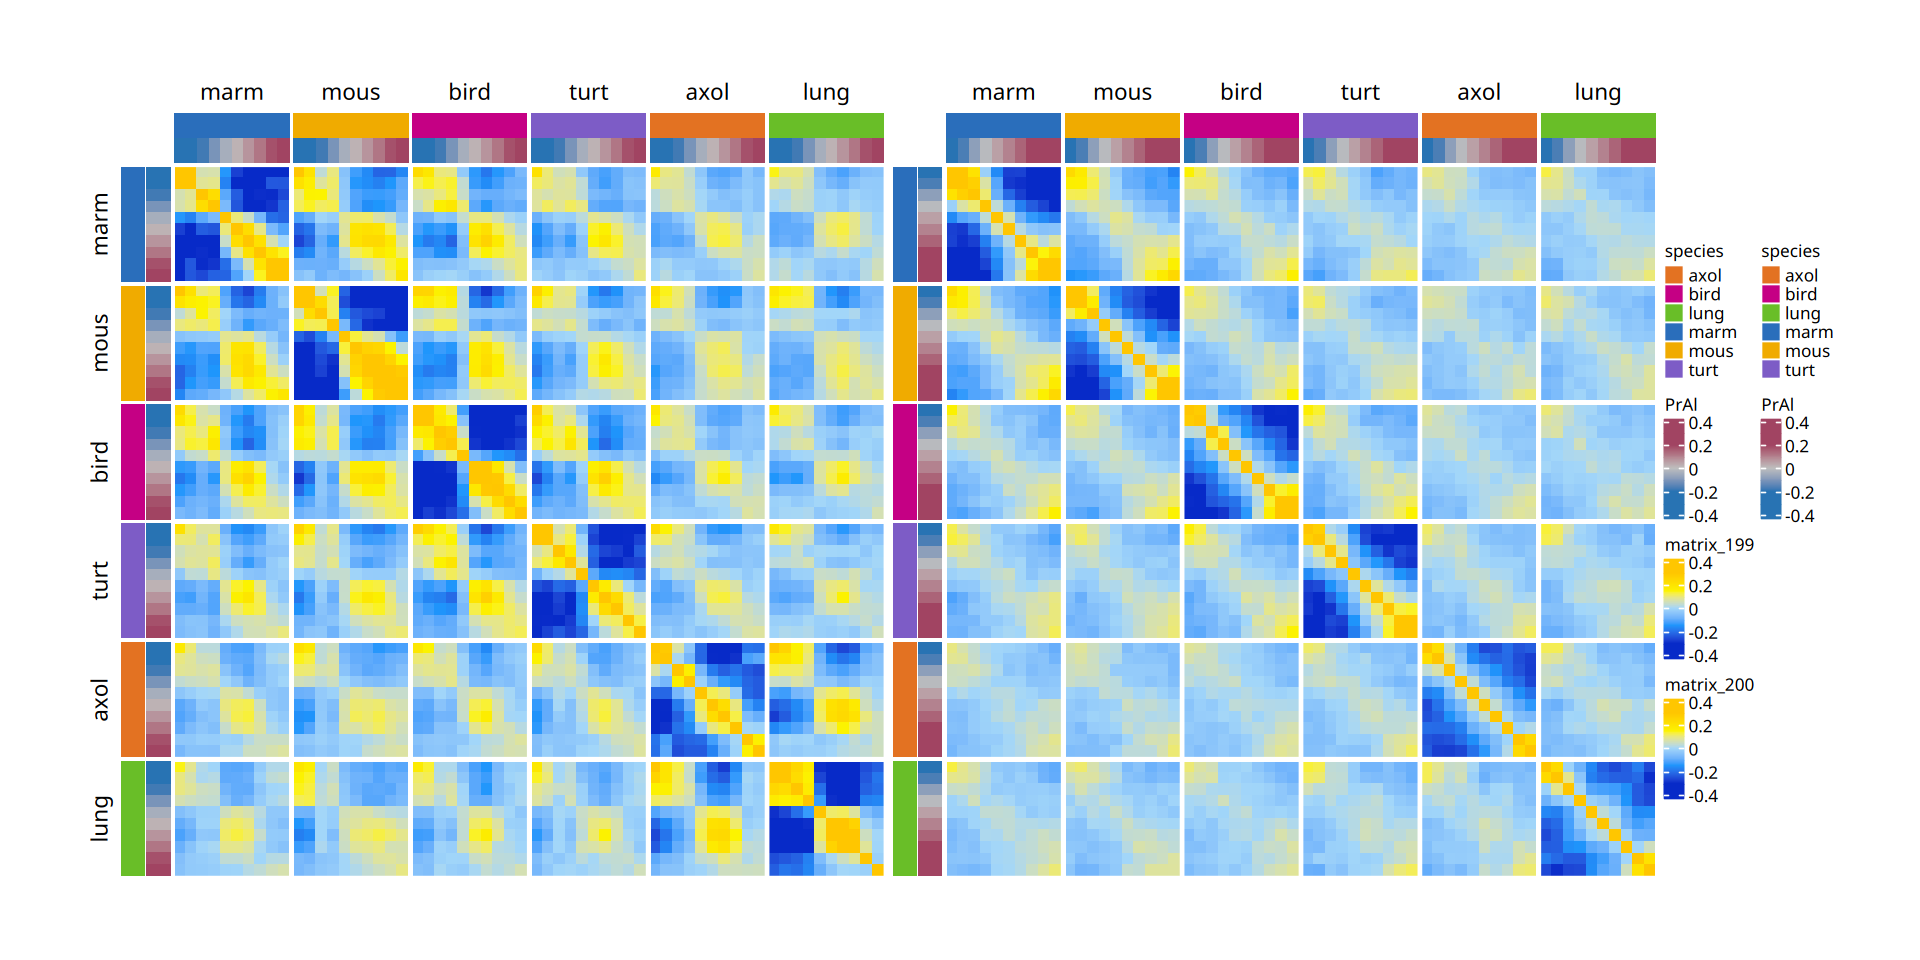

In [ ]:
options(repr.plot.width=16,repr.plot.height=8)
p1 <- plot_tmp_heatmap(PrAl_gene_ae_EX_Species_gradient)
p2 <- plot_tmp_heatmap(PrAl_gene_ae_IN_Species_gradient)
p1+p2

In [ ]:
pdf('Plot/snRNA_PrAl_heatmap/Neuron_CorHeatmap_snPrAl.pdf',width=16,height=8)
p1+p2
dev.off()

pdf 
  2

In [ ]:
obj_EX_smooth <- lapply(c('marm','mous','bird','turt','axol','lung'),function(x){
    obj_tmp <- obj_EX[ ,obj_EX$species==x]
    obj_tmp <- smooth_obj_data(obj_tmp,knn = 25,round = 2,assays='SCT',slot='data',smooth_function = 'magic',reduction = 'harmony',run_PCA = FALSE)
    return(obj_tmp)
})
obj_EX_smooth <- merge(obj_EX_smooth[[1]],obj_EX_smooth[-1])

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 2.4 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 2.7 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 2.2 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.6 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 2.1 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.4 GiB”


In [ ]:
obj_IN_smooth <- lapply(c('marm','mous','bird','turt','axol','lung'),function(x){
    obj_tmp <- obj_IN[ ,obj_IN$species==x]
    obj_tmp <- smooth_obj_data(obj_tmp,knn = 25,round = 2,assays='SCT',slot='data',smooth_function = 'magic',reduction = 'harmony',run_PCA = FALSE)
    return(obj_tmp)
})
obj_IN_smooth <- merge(obj_IN_smooth[[1]],obj_IN_smooth[-1])

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.3 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.2 GiB”


In [ ]:
saveRDS(obj_EX_smooth,'Analysis/obj_GLU_integrated_final_smooth.rds')
saveRDS(obj_IN_smooth,'Analysis/obj_GABA_integrated_final_smooth.rds')

In [ ]:
PrAl_gene_ae_EX_gradient <- as.data.frame(AverageExpression(obj_EX,group.by = c('species','Pr-Al-Type'),assays='SCT',slot='data')$SCT)
PrAl_gene_ae_IN_gradient <- as.data.frame(AverageExpression(obj_IN,group.by = c('species','Pr-Al-Type'),assays='SCT',slot='data')$SCT)
#PrAl_gene_ae_EX <- as.data.frame(AverageExpression(obj_EX,group.by = c('species','type'),assays='SCT',slot='data')$SCT)
#PrAl_gene_ae_IN <- as.data.frame(AverageExpression(obj_IN,group.by = c('species','type'),assays='SCT',slot='data')$SCT)

In [ ]:
source('../R_function/calculate_function.R')
preprocess_Class_df <- function(df){
    obj_gene_all_merge_group <- CreateSeuratObject(df)
    obj_gene_all_merge_group@assays$RNA@meta.features$species <- sapply(rownames(obj_gene_all_merge_group),function(x){return(strsplit(x,'#')[[1]][1])})
    obj_gene_all_merge_group@assays$RNA@meta.features$PrAl_group <- as.numeric(sapply(rownames(obj_gene_all_merge_group),function(x){return(strsplit(x,'#')[[1]][2])}))
    obj_gene_all_merge_group@assays$RNA@meta.features$Class <- sapply(rownames(obj_gene_all_merge_group),function(x){return(strsplit(x,'#')[[1]][3])})
    #obj_gene_all_merge_group@assays$RNA@meta.features$SubClass <- sapply(rownames(obj_gene_all_merge_group),function(x){return(strsplit(x,'#')[[1]][4])})
    obj_gene_all_merge_group@assays$RNA@scale.data <- as.matrix(matrix_group_scale(matrix_input = obj_gene_all_merge_group@assays$RNA@data, 
                                         group.by = paste0(obj_gene_all_merge_group@assays$RNA@meta.features$species,'_',obj_gene_all_merge_group@assays$RNA@meta.features$Class), 
                                         type = "row"))
    
    for(i in unique(obj_gene_all_merge_group@assays$RNA@meta.features$species)){
        tmp_index <- obj_gene_all_merge_group@assays$RNA@meta.features$species==i
        obj_gene_all_merge_group@meta.data[,paste0(i,'_cor')] <- as.numeric(cor(as.matrix(obj_gene_all_merge_group@assays$RNA@data[tmp_index,]),
                                                                                as.matrix(obj_gene_all_merge_group@assays$RNA@meta.features[tmp_index,]$PrAl_group)))
        #obj_gene_all_merge_group@meta.data[is.na(obj_gene_all_merge_group@meta.data[,paste0(i,'_cor')]),paste0(i,'_cor')] <- 0
    }
    
    tmp_df <- obj_gene_all_merge_group@meta.data[,c('marm_cor','mous_cor','bird_cor','turt_cor','axol_cor','lung_cor')]
    for(i in c('marm','mous','bird','turt','axol','lung')){
        tmp_df[!is.na(tmp_df[,paste0(i,'_cor')]),paste0(i,'_cor')] <- i
        tmp_df[is.na(tmp_df[,paste0(i,'_cor')]),paste0(i,'_cor')] <- ''
    }
    obj_gene_all_merge_group$species_included <- apply(X = tmp_df,MARGIN = 1,FUN = function(row) paste(row[row != ""], collapse = "/"))
    obj_gene_all_merge_group$species_included_num <- apply(X = tmp_df,MARGIN = 1,FUN = function(row){length(row[row != ""])})
    for(i in unique(obj_gene_all_merge_group@assays$RNA@meta.features$species)){
        obj_gene_all_merge_group@meta.data[is.na(obj_gene_all_merge_group@meta.data[,paste0(i,'_cor')]),paste0(i,'_cor')] <- 0
    }
    obj_gene_all_merge_group@assays$RNA@var.features <- rownames(obj_gene_all_merge_group)
    obj_gene_all_merge_group <- RunPCA(obj_gene_all_merge_group,verbose = F)                                                   
                                                       
}
#obj_gene_all_merge_group <- FindNeighbors(obj_gene_all_merge_group,reduction = 'pca',dims = 1:5,verbose = F)
#obj_gene_all_merge_group <- FindClusters(obj_gene_all_merge_group,resolution = 0.5,verbose = F)
#obj_gene_all_merge_group <- RunUMAP(obj_gene_all_merge_group,dims = 1:3,n.neighbors = 10,verbose = F)

In [ ]:
df1 <- PrAl_gene_ae_EX_gradient
df2 <- PrAl_gene_ae_IN_gradient
colnames(df1) <- paste0(colnames(df1),'#','EX')
colnames(df2) <- paste0(colnames(df2),'#','IN')
colnames(df1) <- gsub('_','#',colnames(df1))
colnames(df2) <- gsub('_','#',colnames(df2))
intersect_gene <- intersect(rownames(df1),rownames(df2))

In [ ]:
obj_combined_gene <- preprocess_Class_df(t(cbind(df1[intersect_gene,],df2[intersect_gene,])))

Warning message in cor(as.matrix(obj_gene_all_merge_group@assays$RNA@data[tmp_index, :
“the standard deviation is zero”
Warning message in cor(as.matrix(obj_gene_all_merge_group@assays$RNA@data[tmp_index, :
“the standard deviation is zero”
Warning message in cor(as.matrix(obj_gene_all_merge_group@assays$RNA@data[tmp_index, :
“the standard deviation is zero”
Warning message in cor(as.matrix(obj_gene_all_merge_group@assays$RNA@data[tmp_index, :
“the standard deviation is zero”
Warning message in cor(as.matrix(obj_gene_all_merge_group@assays$RNA@data[tmp_index, :
“the standard deviation is zero”
Warning message in cor(as.matrix(obj_gene_all_merge_group@assays$RNA@data[tmp_index, :
“the standard deviation is zero”


In [ ]:
cal_inter_tmp <- function(meta.data,thre){
    Pr_df <- ifelse(meta.data>thre,1,0)
    Al_df <- ifelse(meta.data< -thre,1,0)
    colnames(Pr_df) <- gsub('_cor','',colnames(Pr_df))
    colnames(Al_df) <- gsub('_cor','',colnames(Al_df))
    inter_Pr_df <- upset2inter_s(upset_data = as.data.frame.array(Pr_df))
    inter_Al_df <- upset2inter_s(upset_data = as.data.frame.array(Al_df))
    rownames(inter_Pr_df) <- inter_Pr_df$V1
    rownames(inter_Al_df) <- inter_Al_df$V1
    
    inter_Pr_df$type <- 'Other'
    inter_Al_df$type <- 'Other'
    #inter_Pr_df[ inter_Pr_df$intersection%in%c('marm/mous'),'type'] <- 'Pr_mammal'
    inter_Pr_df[ inter_Pr_df$intersection%in%c('marm/mous/bird'),'type'] <- 'Pr_mammal_bird'
    inter_Pr_df[ inter_Pr_df$intersection%in%c('marm/mous/bird/turt'),'type'] <- 'Pr_amniotes'
    inter_Pr_df[ inter_Pr_df$intersection%in%c('marm/mous/bird/turt/axol'),'type'] <- 'Pr_tetrapoda'
    inter_Pr_df[ inter_Pr_df$intersection%in%c('marm/mous/bird/turt/axol/lung'),'type'] <- 'Pr_shared'
    
    
    #inter_Al_df[ inter_Al_df$intersection%in%c('marm/mous'),'type'] <- 'Al_mammal'
    inter_Al_df[ inter_Al_df$intersection%in%c('marm/mous/bird'),'type'] <- 'Al_mammal_bird'
    inter_Al_df[ inter_Al_df$intersection%in%c('marm/mous/bird/turt'),'type'] <- 'Al_amniotes'
    inter_Al_df[ inter_Al_df$intersection%in%c('marm/mous/bird/turt/axol'),'type'] <- 'Al_tetrapoda'
    inter_Al_df[ inter_Al_df$intersection%in%c('marm/mous/bird/turt/axol/lung'),'type'] <- 'Al_shared'
    return(list('Pr'=inter_Pr_df,'Al'=inter_Al_df))
}

In [ ]:
Combined_result <- cal_inter_tmp(obj_combined_gene@meta.data[,c('marm_cor','mous_cor','bird_cor','turt_cor','axol_cor','lung_cor')],0.25)
obj_combined_gene$Pr_cluster <- Combined_result$Pr[rownames(obj_combined_gene@meta.data),'type']
obj_combined_gene$Al_cluster <- Combined_result$Al[rownames(obj_combined_gene@meta.data),'type']

In [ ]:
source('../R_function/ST_plot.R')

In [ ]:
all_df <- read.csv('Analysis/All_gene_info_Mfuzz.csv',row.names = 1)

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



pdf 
  2

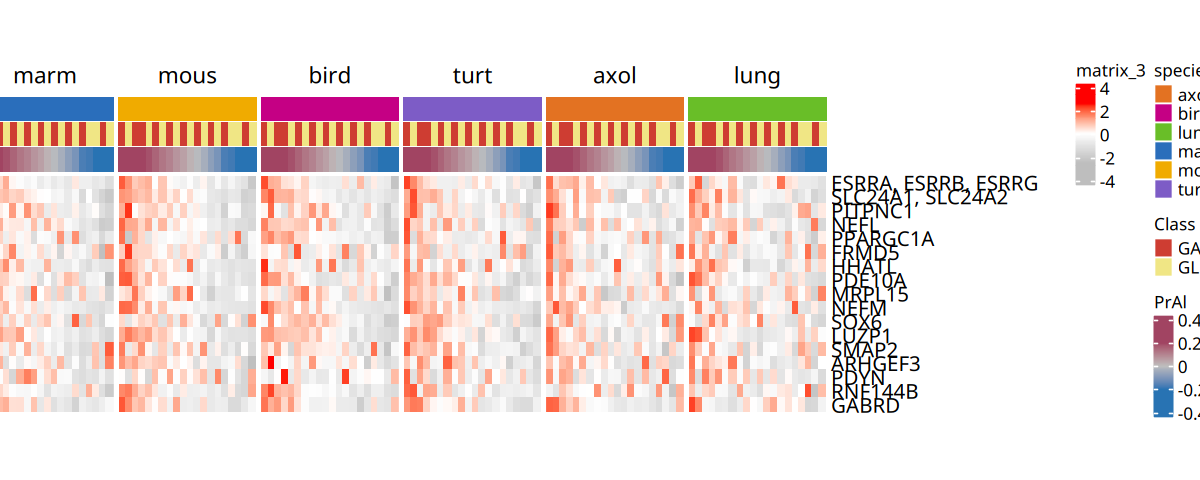

In [ ]:
options(repr.plot.width=10,repr.plot.height=4)
plot_matrix <- t(obj_combined_gene@assays$RNA@scale.data[,obj_combined_gene$Pr_cluster=='Pr_shared'])
plot_matrix <- plot_matrix[,order(obj_combined_gene@assays$RNA@meta.features$PrAl_group,decreasing = T)]
rownames_plot_matrix <- rownames(plot_matrix)
plot_matrix <- as.matrix(dplyr::bind_cols(lapply(c('marm','mous','bird','turt','axol','lung'),function(species){
    plot_tmp <- plot_matrix[,grepl(species,colnames(plot_matrix))]
    return(plot_tmp)
})))
rownames(plot_matrix) <- rownames_plot_matrix

column_split <- sapply(colnames(plot_matrix),function(x){return(strsplit(x,'#')[[1]][1])})
column_split <- factor(column_split,levels = c('marm','mous','bird','turt','axol','lung'))

col_annotation <- columnAnnotation(species = sapply(colnames(plot_matrix),function(x){return(strsplit(x,'#')[[1]][1])}),
                                   Class = as.character(c('IN'='GABA','EX'='GLU')[sapply(colnames(plot_matrix),function(x){return(strsplit(x,'#')[[1]][3])})]),
                                    PrAl = as.numeric(sapply(colnames(plot_matrix),function(x){return(strsplit(x,'#')[[1]][2])})),                              
                                show_annotation_name = FALSE,show_legend=TRUE,
                                col=list(
                                    species=Species_color,
                                    Class=c('GLU'='#F0E685FF','GABA'='#CE3D32FF'),
                                    PrAl=colorRamp2(seq(-0.4,0.4,length.out = 5), c('#2873B3','#2873B3','gray','#A14462','#A14462'))
                                ))
rownames(plot_matrix) <- all_df[rownames(plot_matrix),'Marmoset.pep']

p1 <- ComplexHeatmap::Heatmap(plot_matrix,top_annotation = col_annotation,
                              column_split = column_split,
                              cluster_rows = F,cluster_columns = F,show_row_dend = F,show_column_names = F,
                              show_row_names=T,use_raster = T,
                              width =ncol(plot_matrix)*unit(180/ncol(plot_matrix), "mm"),
                              height=nrow(plot_matrix)*unit(50/nrow(plot_matrix), "mm"),
                              col =  c('gray','white','red'))
p1
pdf('Plot/snRNA_Pr_conserved_heatmap.pdf',width=10,height=4)
p1
dev.off()

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



pdf 
  2

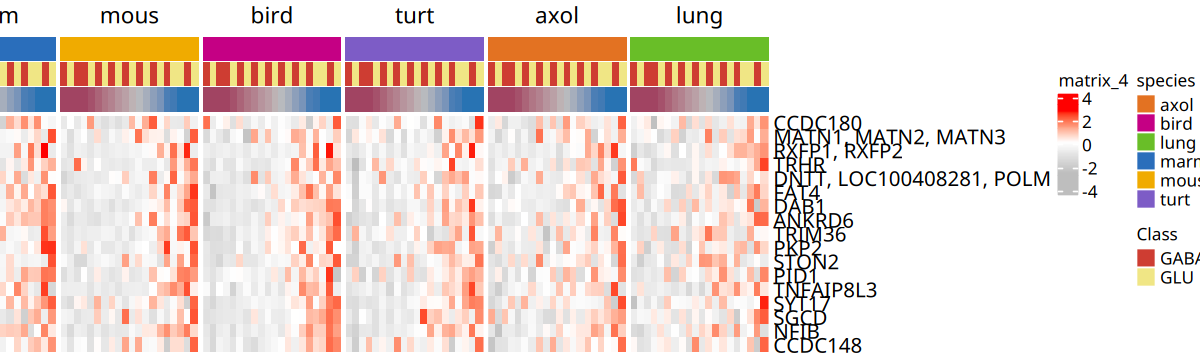

In [ ]:
options(repr.plot.width=10,repr.plot.height=3)
plot_matrix <- t(obj_combined_gene@assays$RNA@scale.data[,obj_combined_gene$Al_cluster=='Al_shared'])
plot_matrix <- plot_matrix[,order(obj_combined_gene@assays$RNA@meta.features$PrAl_group,decreasing = T)]
rownames_plot_matrix <- rownames(plot_matrix)
plot_matrix <- as.matrix(dplyr::bind_cols(lapply(c('marm','mous','bird','turt','axol','lung'),function(species){
    plot_tmp <- plot_matrix[,grepl(species,colnames(plot_matrix))]
    return(plot_tmp)
})))
rownames(plot_matrix) <- rownames_plot_matrix

column_split <- sapply(colnames(plot_matrix),function(x){return(strsplit(x,'#')[[1]][1])})
column_split <- factor(column_split,levels = c('marm','mous','bird','turt','axol','lung'))

col_annotation <- columnAnnotation(species = sapply(colnames(plot_matrix),function(x){return(strsplit(x,'#')[[1]][1])}),
                                   Class = as.character(c('IN'='GABA','EX'='GLU')[sapply(colnames(plot_matrix),function(x){return(strsplit(x,'#')[[1]][3])})]),
                                    PrAl = as.numeric(sapply(colnames(plot_matrix),function(x){return(strsplit(x,'#')[[1]][2])})),                              
                                show_annotation_name = FALSE,show_legend=TRUE,
                                col=list(
                                    species=Species_color,
                                    Class=c('GLU'='#F0E685FF','GABA'='#CE3D32FF'),
                                    PrAl=colorRamp2(seq(-0.4,0.4,length.out = 5), c('#2873B3','#2873B3','gray','#A14462','#A14462'))
                                ))
rownames(plot_matrix) <- all_df[rownames(plot_matrix),'Marmoset.pep']

p2 <- ComplexHeatmap::Heatmap(plot_matrix,top_annotation = col_annotation,
                              column_split = column_split,
                              cluster_rows = F,cluster_columns = F,show_row_dend = F,show_column_names = F,
                              show_row_names=T,use_raster = T,
                              width =ncol(plot_matrix)*unit(180/ncol(plot_matrix), "mm"),
                              height=nrow(plot_matrix)*unit(50/nrow(plot_matrix), "mm"),
                              col =  c('gray','white','red'))
p2
pdf('Plot/snRNA_Al_conserved_heatmap.pdf',width=10,height=4)
p2
dev.off()